## Introduction

#  Duress-Aware Banking: AI-Driven Detection of Unsafe User Behaviour through Multi-Modal Anomaly Analysis
This notebook develops a duress-aware banking system by combining transactional anomaly detection with behavioural keystroke modelling to detect unsafe or coerced user behaviour using multi-modal anomaly analysis. Unlike traditional fraud detection, it targets situations where legitimate users may act under **duress**, reframing detection as a **human safety and trustworthy AI** problem.

### Transactional Modelling
Four supervised models are trained on the IEEE-CIS dataset:

- **Random Forest (RF)**
- **XGBoost**
- **LightGBM (Class-Weighted)**
- **LightGBM (SMOTE-Enhanced)**

Class imbalance is addressed using **class weights** and **SMOTE**, allowing the models to better learn minority (fraud-like) behaviour. Random Forest is ultimately selected as the primary transactional model based on F1-Score and PR-AUC.

### Behavioural Modelling
Keystroke behaviour is analysed using an **Autoencoder**, trained only on normal typing patterns. Reconstruction error is used to detect irregular, stress-induced or duress-like typing behaviour.

### Duress Risk Estimation
Each model produces a risk score. These signals are standardised and combined to estimate an overall **Duress Risk Score**, evaluated using:

- Precision, Recall, F1-Score  
- ROC-AUC & PR-AUC  
- **Recall at 1% False Positive Rate (FPR)**  
- Visualisations (ROC curves, reconstruction error, etc.)

The notebook concludes with an interactive `ipywidgets` prototype that simulates real-time duress-risk scoring and a SHAP explanation module to illustrate how the risk is computed.



## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Libraries Importation</div>

In [1]:
pip install -U imbalanced-learn


Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install scikit-learn==1.7.0


Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
from imblearn.over_sampling import SMOTE

print("All imports successful!")


All imports successful!


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Dataset Importation</div>

In [4]:
#  LOAD AND MERGE IEEE-CIS DATASETS 

# Load transaction and identity datasets
train_trans = pd.read_csv("data/train_transaction.csv")
train_id = pd.read_csv("data/train_identity.csv")

print("✅ Raw datasets loaded successfully!")
print(f"Transactions Shape: {train_trans.shape}")
print(f"Identity Shape: {train_id.shape}\n")

# Merge on TransactionID
ieee = train_trans.merge(train_id, on="TransactionID", how="left")

print("✅ IEEE-CIS Fraud Detection dataset merged!")
print(f"Merged Shape: {ieee.shape}\n")

# Load keystroke dataset
keys = pd.read_csv("data/keystroke_dynamics.csv")

print(f"✅ Keystroke Dataset Loaded: {keys.shape}\n")

# Preview data
print("IEEE-CIS Fraud Detection Dataset:")
display(ieee.head())

print("\nKeystroke Dynamics Dataset:")
display(keys.head())


✅ Raw datasets loaded successfully!
Transactions Shape: (590540, 394)
Identity Shape: (144233, 41)

✅ IEEE-CIS Fraud Detection dataset merged!
Merged Shape: (590540, 434)

✅ Keystroke Dataset Loaded: (20400, 34)

IEEE-CIS Fraud Detection Dataset:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



Keystroke Dynamics Dataset:


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


In [5]:
# SAVE MERGED IEEE DATASET

ieee.to_csv("data/ieee_cis_fraud.csv", index=False)
print(" Merged dataset saved as ieee_cis_fraud.csv")


 Merged dataset saved as ieee_cis_fraud.csv


In [6]:
# === CHECK THE FIRST FEW ROWS ===
print("IEEE-CIS Fraud Detection Dataset:")
display(ieee.head())

print("\nKeystroke Dynamics Dataset:")
display(keys.head())

IEEE-CIS Fraud Detection Dataset:


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,...,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M



Keystroke Dynamics Dataset:


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Exploratory Data Analysis (EDA)</div>

In [7]:
print(ieee.shape)
print(keys.shape)


(590540, 434)
(20400, 34)


In [8]:
ieee.dtypes
keys.dtypes


subject             object
sessionIndex         int64
rep                  int64
H.period           float64
DD.period.t        float64
UD.period.t        float64
H.t                float64
DD.t.i             float64
UD.t.i             float64
H.i                float64
DD.i.e             float64
UD.i.e             float64
H.e                float64
DD.e.five          float64
UD.e.five          float64
H.five             float64
DD.five.Shift.r    float64
UD.five.Shift.r    float64
H.Shift.r          float64
DD.Shift.r.o       float64
UD.Shift.r.o       float64
H.o                float64
DD.o.a             float64
UD.o.a             float64
H.a                float64
DD.a.n             float64
UD.a.n             float64
H.n                float64
DD.n.l             float64
UD.n.l             float64
H.l                float64
DD.l.Return        float64
UD.l.Return        float64
H.Return           float64
dtype: object

In [9]:
# check for missing values
ieee.isna().sum()
keys.isna().sum()


subject            0
sessionIndex       0
rep                0
H.period           0
DD.period.t        0
UD.period.t        0
H.t                0
DD.t.i             0
UD.t.i             0
H.i                0
DD.i.e             0
UD.i.e             0
H.e                0
DD.e.five          0
UD.e.five          0
H.five             0
DD.five.Shift.r    0
UD.five.Shift.r    0
H.Shift.r          0
DD.Shift.r.o       0
UD.Shift.r.o       0
H.o                0
DD.o.a             0
UD.o.a             0
H.a                0
DD.a.n             0
UD.a.n             0
H.n                0
DD.n.l             0
UD.n.l             0
H.l                0
DD.l.Return        0
UD.l.Return        0
H.Return           0
dtype: int64

In [10]:
print("IEEE duplicates:", ieee.duplicated().sum())
print("Keys duplicates:", keys.duplicated().sum())


IEEE duplicates: 0
Keys duplicates: 0


In [11]:
# CATEGORICAL FEATURES EXPLORATION 
print("\n--- Categorical Columns (IEEE) ---")
for col in ieee.select_dtypes(include='object').columns:
    print(f"\nColumn: {col}")
    print(ieee[col].unique()[:10])




--- Categorical Columns (IEEE) ---

Column: ProductCD
['W' 'H' 'C' 'S' 'R']

Column: card4
['discover' 'mastercard' 'visa' 'american express' nan]

Column: card6
['credit' 'debit' nan 'debit or credit' 'charge card']

Column: P_emaildomain
[nan 'gmail.com' 'outlook.com' 'yahoo.com' 'mail.com' 'anonymous.com'
 'hotmail.com' 'verizon.net' 'aol.com' 'me.com']

Column: R_emaildomain
[nan 'gmail.com' 'hotmail.com' 'outlook.com' 'anonymous.com' 'charter.net'
 'prodigy.net.mx' 'comcast.net' 'live.com.mx' 'icloud.com']

Column: M1
['T' nan 'F']

Column: M2
['T' nan 'F']

Column: M3
['T' nan 'F']

Column: M4
['M2' 'M0' nan 'M1']

Column: M5
['F' 'T' nan]

Column: M6
['T' 'F' nan]

Column: M7
[nan 'F' 'T']

Column: M8
[nan 'F' 'T']

Column: M9
[nan 'F' 'T']

Column: id_12
[nan 'NotFound' 'Found']

Column: id_15
[nan 'New' 'Found' 'Unknown']

Column: id_16
[nan 'NotFound' 'Found']

Column: id_23
[nan 'IP_PROXY:TRANSPARENT' 'IP_PROXY:ANONYMOUS' 'IP_PROXY:HIDDEN']

Column: id_27
[nan 'Found' 'NotF

In [12]:
for col in keys.columns:
    if keys[col].dtype == 'object':
        print(f"\nColumn: {col}")
        print(keys[col].unique()[:10])



Column: subject
['s002' 's003' 's004' 's005' 's007' 's008' 's010' 's011' 's012' 's013']


In [13]:
# BASIC STATISTICS
print("\n--- IEEE Numerical Features Stats ---")
display(ieee.select_dtypes(include=np.number).describe().T.head(10))

print("\n--- Keystroke Numerical Features Stats ---")
display(keys.select_dtypes(include=np.number).describe().T.head(10))


--- IEEE Numerical Features Stats ---


,count,mean,std,min,25%,50%,75%,max
TransactionID,590540.0,3.282270e+06,1.704744e+05,2987000.000,3134634.750,3282269.500,3429904.25,3.577539e+06
isFraud,590540.0,3.499001e-02,1.837546e-01,0.000,0.000,0.000,0.00,1.000000e+00
TransactionDT,590540.0,7.372311e+06,4.617224e+06,86400.000,3027057.750,7306527.500,11246620.00,1.581113e+07
TransactionAmt,590540.0,1.350272e+02,2.391625e+02,0.251,43.321,68.769,125.00,3.193739e+04
card1,590540.0,9.898735e+03,4.901170e+03,1000.000,6019.000,9678.000,14184.00,1.839600e+04
card2,581607.0,3.625555e+02,1.577932e+02,100.000,214.000,361.000,512.00,6.000000e+02
card3,588975.0,1.531949e+02,1.133644e+01,100.000,150.000,150.000,150.00,2.310000e+02
card5,586281.0,1.992789e+02,4.124445e+01,100.000,166.000,226.000,226.00,2.370000e+02
addr1,524834.0,2.907338e+02,1.017411e+02,100.000,204.000,299.000,330.00,5.400000e+02
addr2,524834.0,8.680063e+01,2.690623e+00,10.000,87.000,87.000,87.00,1.020000e+02



--- Keystroke Numerical Features Stats ---


,count,mean,std,min,25%,50%,75%,max
sessionIndex,20400.0,4.500000,2.291344,1.0000,2.7500,4.50000,6.25000,8.0000
rep,20400.0,25.500000,14.431223,1.0000,13.0000,25.50000,38.00000,50.0000
H.period,20400.0,0.093379,0.029626,0.0014,0.0744,0.08950,0.10790,0.3761
DD.period.t,20400.0,0.264148,0.220534,0.0187,0.1469,0.20595,0.30645,12.5061
UD.period.t,20400.0,0.170769,0.226836,-0.2358,0.0498,0.10870,0.21240,12.4517
H.t,20400.0,0.085727,0.027424,0.0093,0.0660,0.08100,0.09980,0.2411
DD.t.i,20400.0,0.169085,0.123546,0.0011,0.1136,0.14040,0.18390,4.9197
UD.t.i,20400.0,0.083358,0.125755,-0.1621,0.0272,0.05780,0.09640,4.7999
H.i,20400.0,0.081565,0.026887,0.0032,0.0620,0.07710,0.09690,0.3312
DD.i.e,20400.0,0.159372,0.226928,0.0014,0.0893,0.12090,0.17310,25.9873


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Visualization</div>

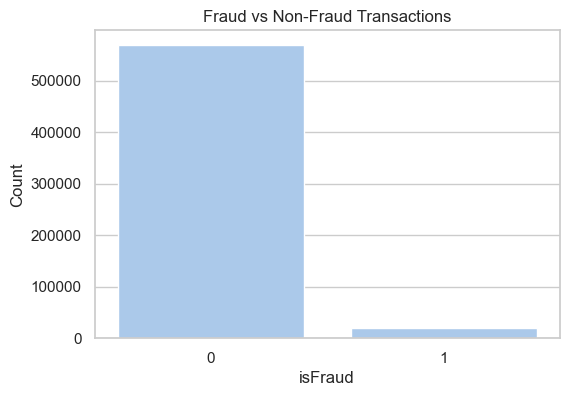

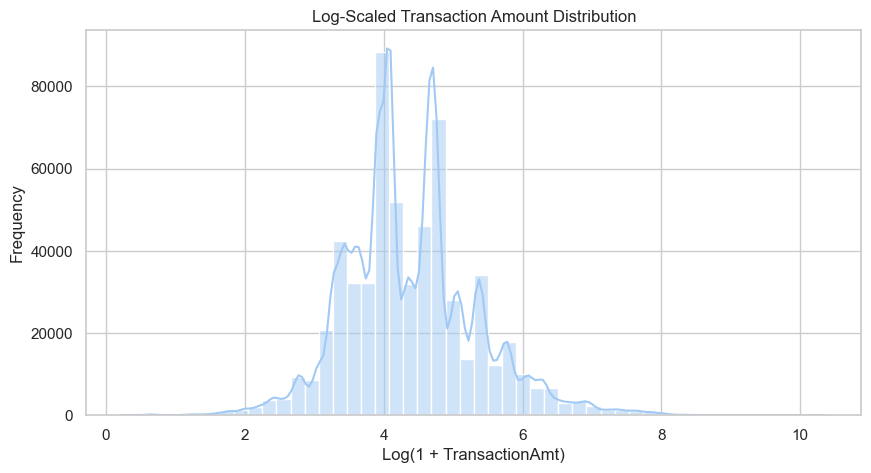

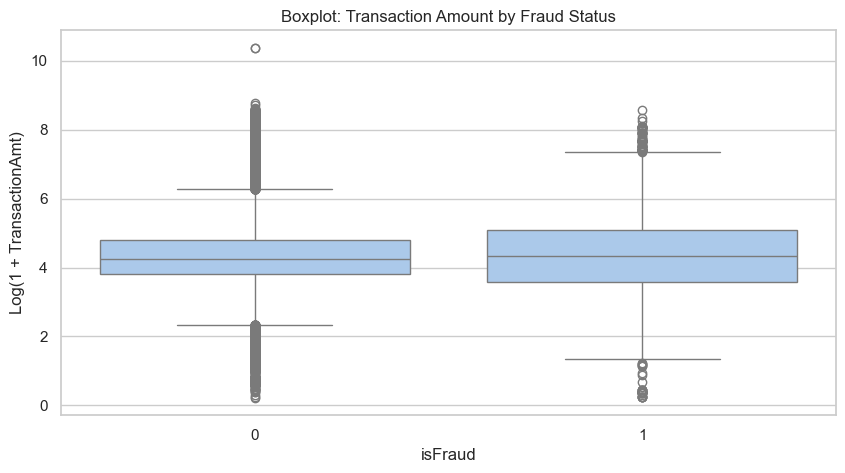

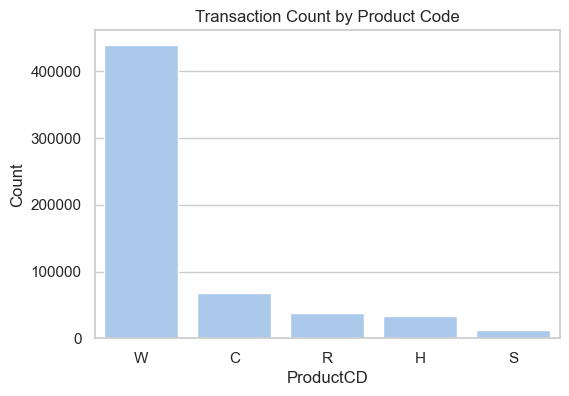

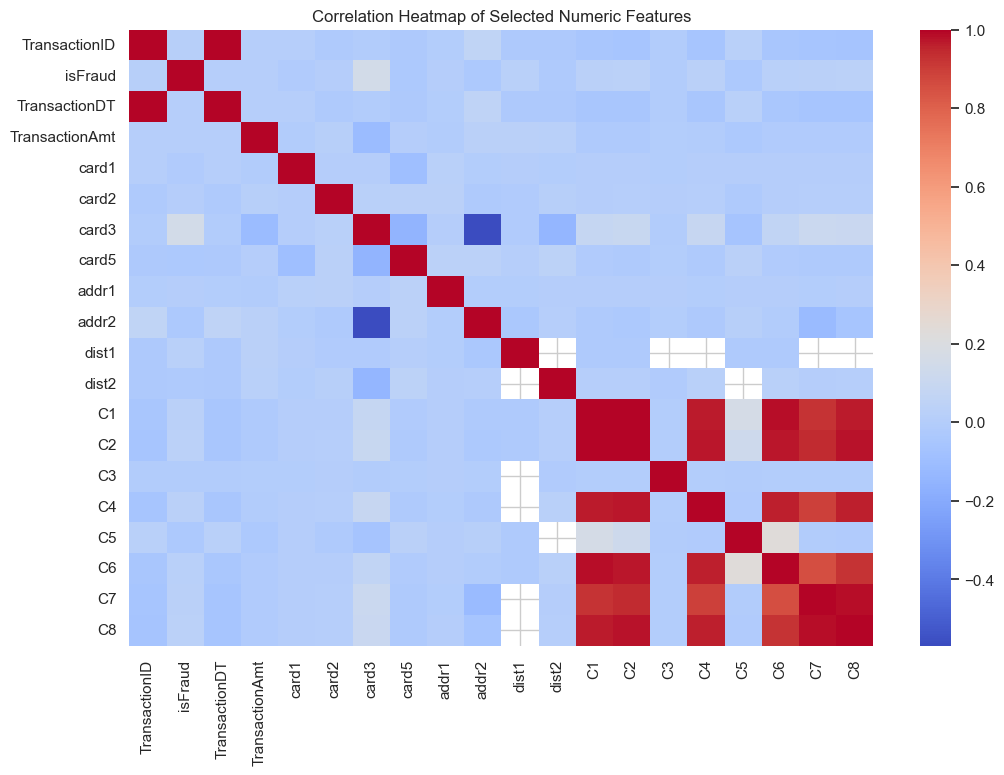

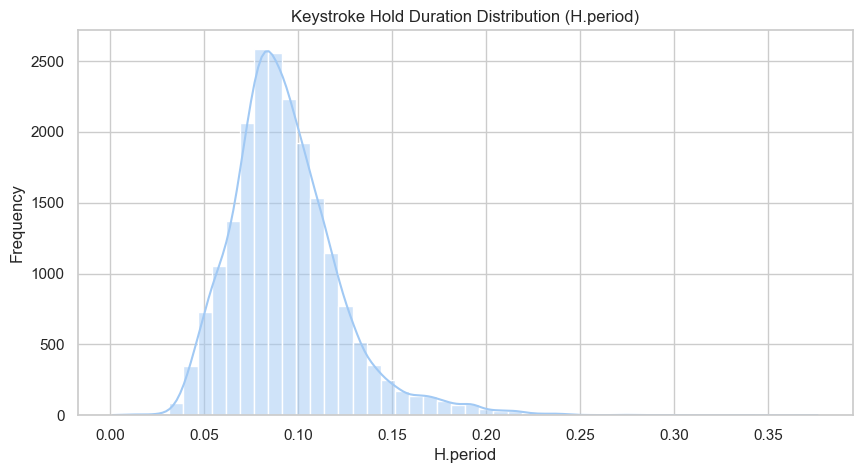

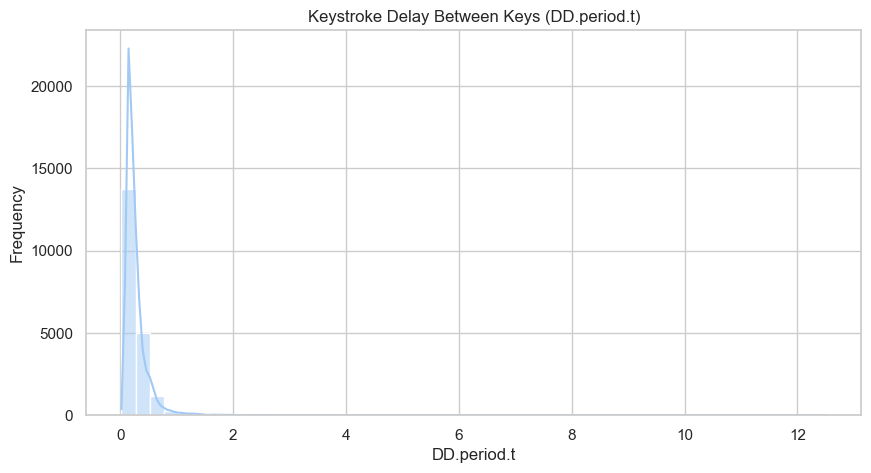

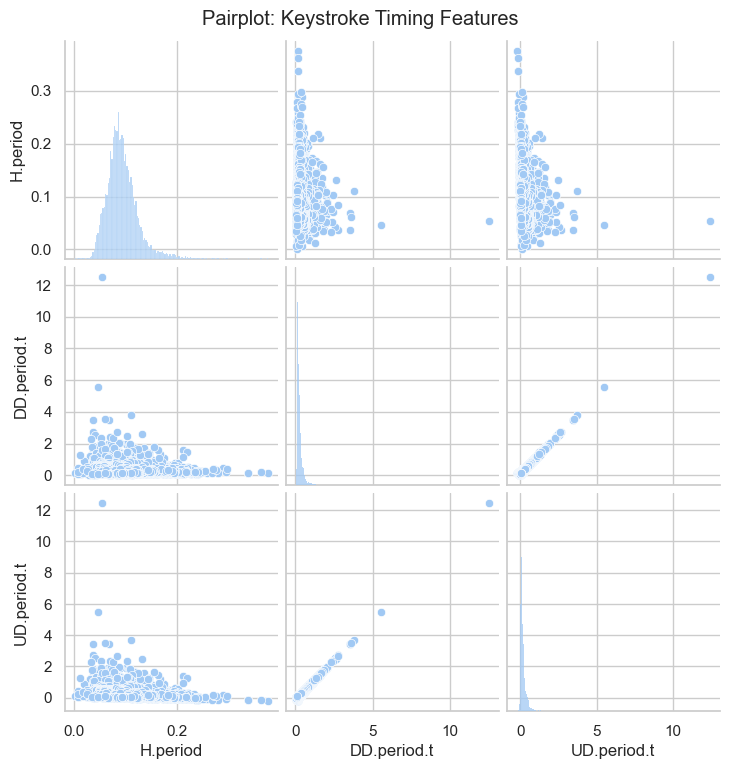

In [14]:
# === Exploratory Data Analysis (EDA) ===
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid", palette="pastel")

#  Fraud vs Non-Fraud Transactions
plt.figure(figsize=(6,4))
sns.countplot(x="isFraud", data=ieee)
plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("isFraud")
plt.ylabel("Count")
plt.show()

# Transaction Amount Distribution (log-scaled)
plt.figure(figsize=(10,5))
sns.histplot(np.log1p(ieee['TransactionAmt']), bins=50, kde=True)
plt.title("Log-Scaled Transaction Amount Distribution")
plt.xlabel("Log(1 + TransactionAmt)")
plt.ylabel("Frequency")
plt.show()

#  Boxplot: Transaction Amount by Fraud Status
plt.figure(figsize=(10,5))
sns.boxplot(x="isFraud", y=np.log1p(ieee['TransactionAmt']), data=ieee)
plt.title("Boxplot: Transaction Amount by Fraud Status")
plt.xlabel("isFraud")
plt.ylabel("Log(1 + TransactionAmt)")
plt.show()

#  Product Code Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="ProductCD", data=ieee, order=ieee['ProductCD'].value_counts().index)
plt.title("Transaction Count by Product Code")
plt.xlabel("ProductCD")
plt.ylabel("Count")
plt.show()

#  Correlation Heatmap (first 20 numeric features)
plt.figure(figsize=(12,8))
numeric_cols = ieee.select_dtypes(include=np.number).columns.tolist()
sns.heatmap(ieee[numeric_cols[:20]].corr(), cmap='coolwarm', annot=False)
plt.title("Correlation Heatmap of Selected Numeric Features")
plt.show()

#  Keystroke Hold Duration Distribution (H.period)
plt.figure(figsize=(10,5))
sns.histplot(keys['H.period'], bins=50, kde=True)
plt.title("Keystroke Hold Duration Distribution (H.period)")
plt.xlabel("H.period")
plt.ylabel("Frequency")
plt.show()

#  Key Latency Distribution (DD.period.t)
plt.figure(figsize=(10,5))
sns.histplot(keys['DD.period.t'], bins=50, kde=True)
plt.title("Keystroke Delay Between Keys (DD.period.t)")
plt.xlabel("DD.period.t")
plt.ylabel("Frequency")
plt.show()

#  Pairplot of Keystroke Features
sns.pairplot(keys[['H.period','DD.period.t','UD.period.t']])
plt.suptitle("Pairplot: Keystroke Timing Features", y=1.02)
plt.show()


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Data Preprocessing</div>

In [15]:

from sklearn.preprocessing import LabelEncoder, StandardScaler

# Drop columns with >50% missing values
high_missing_cols = ieee.isna().mean()[ieee.isna().mean() > 0.5].index
ieee.drop(columns=high_missing_cols, inplace=True)
print(f"Dropped {len(high_missing_cols)} high-missing columns from IEEE.")




Dropped 214 high-missing columns from IEEE.


# Encode Categorial Variables


 Encoded Categorical Columns:
['ProductCD', 'card4', 'card6', 'P_emaildomain', 'M1', 'M2', 'M3', 'M4', 'M6']

--- First 5 Rows after Encoding ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,2987000,0,86400,68.5,4,13926,NaN,150.0,1,142.0,...,0.0,0.0,0.0,0.0,0.0,117.0,0.0,0.0,0.0,0.0
1,2987001,0,86401,29.0,4,2755,404.0,150.0,2,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2987002,0,86469,59.0,4,4663,490.0,150.0,4,166.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2987003,0,86499,50.0,4,18132,567.0,150.0,2,117.0,...,135.0,0.0,0.0,0.0,50.0,1404.0,790.0,0.0,0.0,0.0
4,2987004,0,86506,50.0,1,4497,514.0,150.0,2,102.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


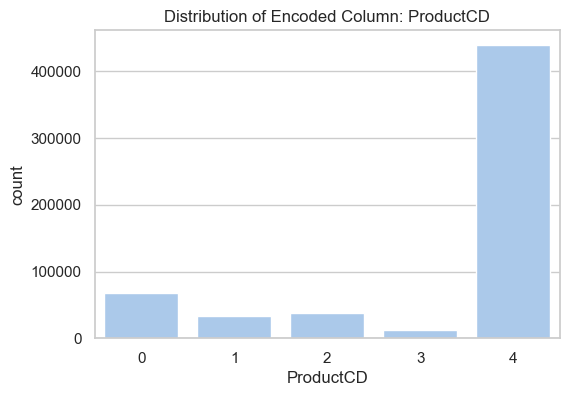

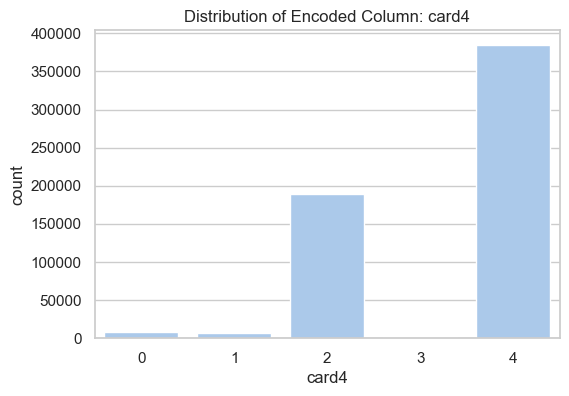

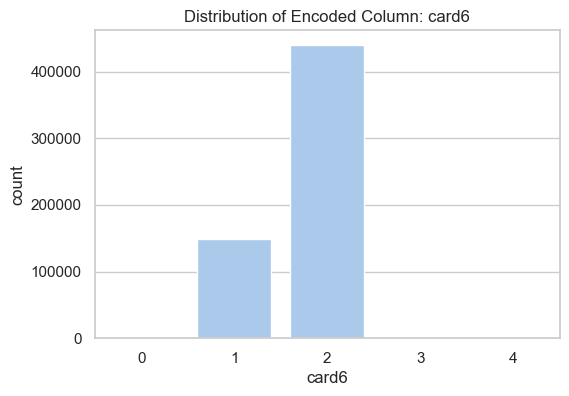

In [16]:
categorical_cols = ieee.select_dtypes(include='object').columns
encoded_cols = []

for col in categorical_cols:
    ieee[col] = ieee[col].fillna("unknown")
    le = LabelEncoder()
    ieee[col] = le.fit_transform(ieee[col])
    encoded_cols.append(col)

print("\n Encoded Categorical Columns:")
print(encoded_cols)

# Display first few rows with encoded variables
print("\n--- First 5 Rows after Encoding ---")
display(ieee.head()) 

 # showing distribution of a few encoded categorical columns
import matplotlib.pyplot as plt
import seaborn as sns

for col in encoded_cols[:3]:  # first 3 for example
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=ieee)
    plt.title(f"Distribution of Encoded Column: {col}")
    plt.show()

In [17]:

#  Scale numeric features (IEEE)
numeric_cols = ieee.select_dtypes(include=np.number).columns.tolist()
numeric_cols.remove('isFraud')  # keep target unscaled
scaler = StandardScaler()
ieee[numeric_cols] = scaler.fit_transform(ieee[numeric_cols])

# Display first few rows after scaling numeric features
print("\n--- First 5 Rows after Scaling Numeric Features ---")
display(ieee.head())


--- First 5 Rows after Scaling Numeric Features ---


,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,...,V312,V313,V314,V315,V316,V317,V318,V319,V320,V321
0,-1.732048,0,-1.577987,-0.278167,0.547250,0.821695,NaN,-0.281828,-2.187837,-1.388767,...,-0.227586,-0.222636,-0.249507,-0.229407,-0.048378,-0.032815,-0.058050,-0.055288,-0.088856,-0.074143
1,-1.732042,0,-1.577986,-0.443327,0.547250,-1.457558,0.262651,-0.281828,-1.222461,-2.358595,...,-0.227586,-0.222636,-0.249507,-0.229407,-0.048378,-0.062212,-0.058050,-0.055288,-0.088856,-0.074143
2,-1.732036,0,-1.577972,-0.317889,0.547250,-1.068263,0.807668,-0.281828,0.708291,-0.806870,...,-0.227586,-0.222636,-0.249507,-0.229407,-0.048378,-0.062212,-0.058050,-0.055288,-0.088856,-0.074143
3,-1.732030,0,-1.577965,-0.355521,0.547250,1.679858,1.295649,-0.281828,-1.222461,-1.994910,...,0.556714,-0.222636,-0.249507,-0.229407,-0.026351,0.290548,0.224765,-0.055288,-0.088856,-0.074143
4,-1.732024,0,-1.577964,-0.355521,-1.559603,-1.102133,0.959766,-0.281828,-1.222461,-2.358595,...,-0.227586,-0.222636,-0.249507,-0.229407,-0.048378,-0.062212,-0.058050,-0.055288,-0.088856,-0.074143


In [18]:

# Keystroke Dataset Preprocessing 
keystroke_numeric = keys.select_dtypes(include=np.number).columns.tolist()
if 'TransactionID' in keystroke_numeric:
    keystroke_numeric.remove('TransactionID')

scaler_keys = StandardScaler()
keys[keystroke_numeric] = scaler_keys.fit_transform(keys[keystroke_numeric])

# Display first few rows after scaling keystrokes
print("\n--- Keystroke Dataset After Scaling ---")
display(keys.head())

print("\n✅ Preprocessing completed for both datasets!")


--- Keystroke Dataset After Scaling ---


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,-1.527525,-1.697749,1.880895,0.606507,0.344004,0.772068,-0.013637,-0.181768,1.314223,...,0.737647,-0.021132,-0.293845,0.107385,0.991227,0.912275,1.347947,0.128903,-0.039690,-0.513862
1,s002,-1.527525,-1.628453,0.598189,0.367082,0.278757,-0.595367,-0.330127,-0.194492,0.343466,...,0.899904,0.978686,0.667235,0.803611,0.409953,0.231057,-0.412333,-0.205194,-0.149765,-0.495648
2,s002,-1.527525,-1.559158,1.330682,-0.258235,-0.424852,-0.460447,-0.323652,-0.217553,0.019881,...,1.438188,0.768296,0.253714,0.888199,0.451900,0.254244,0.455460,-0.164819,-0.216936,0.225629
3,s002,-1.527525,-1.489862,1.205786,-0.057354,-0.213240,0.735603,0.650911,0.479058,0.834424,...,1.015803,0.113852,-0.258672,-0.107338,0.209536,0.217896,-0.391168,0.006002,0.053916,-0.255223
4,s002,-1.527525,-1.420566,1.064014,-0.147138,-0.282014,0.137578,-0.012019,-0.041810,0.324870,...,0.642353,0.070099,-0.165511,-0.048777,0.326723,0.316914,-0.186566,-0.311236,-0.281074,-0.237009



✅ Preprocessing completed for both datasets!


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Data Spliting</div>

In [19]:
from sklearn.model_selection import train_test_split
import pandas as pd

#  IEEE dataset 
X_ieee = ieee.drop('isFraud', axis=1)
y_ieee = ieee['isFraud']

X_train_ieee, X_test_ieee, y_train_ieee, y_test_ieee = train_test_split(
    X_ieee, y_ieee, test_size=0.2, random_state=42, stratify=y_ieee
)

print(" IEEE dataset split completed.")
print("Train shape:", X_train_ieee.shape, "Test shape:", X_test_ieee.shape)


# Keystroke dataset 
# Add duress_label if missing
if 'duress_label' not in keys.columns:
    print("⚠️ 'duress_label' column not found — creating simulated labels...")
    keys['duress_label'] = 0
    duress_indices = keys.sample(frac=0.1, random_state=42).index
    keys.loc[duress_indices, 'duress_label'] = 1
    print(" Simulated duress labels added!")

# Drop only if the column exists
drop_cols = [col for col in ['subject', 'duress_label'] if col in keys.columns]
X_keys = keys.drop(columns=drop_cols)
y_keys = keys['duress_label']

X_train_keys, X_test_keys, y_train_keys, y_test_keys = train_test_split(
    X_keys, y_keys, test_size=0.2, random_state=42, stratify=y_keys
)

print("\n Keystroke dataset split completed.")
print("Train shape:", X_train_keys.shape, "Test shape:", X_test_keys.shape)


 IEEE dataset split completed.
Train shape: (472432, 219) Test shape: (118108, 219)
⚠️ 'duress_label' column not found — creating simulated labels...
 Simulated duress labels added!

 Keystroke dataset split completed.
Train shape: (16320, 33) Test shape: (4080, 33)


In [20]:
#  IEEE dataset
X_ieee = ieee.drop('isFraud', axis=1)
y_ieee = ieee['isFraud']

X_train_ieee, X_test_ieee, y_train_ieee, y_test_ieee = train_test_split(
    X_ieee, y_ieee, test_size=0.2, random_state=42, stratify=y_ieee
)

# --- Keystroke dataset ---
X_keys = keys.drop(['subject','duress_label'], axis=1)
y_keys = keys['duress_label']

X_train_keys, X_test_keys, y_train_keys, y_test_keys = train_test_split(
    X_keys, y_keys, test_size=0.2, random_state=42, stratify=y_keys
)

print(" IEEE dataset split completed.")
print("Train shape:", X_train_ieee.shape, "Test shape:", X_test_ieee.shape)
print(" Keystroke dataset split completed.")
print("Train shape:", X_train_keys.shape, "Test shape:", X_test_keys.shape)


 IEEE dataset split completed.
Train shape: (472432, 219) Test shape: (118108, 219)
 Keystroke dataset split completed.
Train shape: (16320, 33) Test shape: (4080, 33)


In [21]:
import numpy as np
import pandas as pd

# The code requires X_train_ieee to be defined and run from the preceding cell.

# 1. Identify all columns that are of type 'object' or 'category' 
# (These are the non-numeric/unencoded categorical columns for SMOTENC)
categorical_feature_names = X_train_ieee.select_dtypes(include=['object', 'category']).columns.tolist()

# 2. Get the numerical index (position) for each of those columns
# This list is what SMOTENC requires
cat_indices = [X_train_ieee.columns.get_loc(col) for col in categorical_feature_names]

print("--- Final Categorical Indices for SMOTENC ---")
print(f"Number of Categorical Features Found: {len(categorical_feature_names)}")
print(f"Categorical Columns: {categorical_feature_names}")
print(f"Numerical Indices for SMOTENC: {cat_indices}")

--- Final Categorical Indices for SMOTENC ---
Number of Categorical Features Found: 0
Categorical Columns: []
Numerical Indices for SMOTENC: []


# HANDLE CLASS IMBALANCE USING SMOTE (ONLY ON TRAIN SET)

In [22]:
!pip install --upgrade imbalanced-learn


  Using cached imbalanced_learn-0.14.1-py3-none-any.whl.metadata (8.9 kB)
  Using cached sklearn_compat-0.1.5-py3-none-any.whl.metadata (20 kB)
Using cached imbalanced_learn-0.14.1-py3-none-any.whl (235 kB)
Using cached sklearn_compat-0.1.5-py3-none-any.whl (20 kB)
  Attempting uninstall: sklearn-compat
    Found existing installation: sklearn-compat 0.1.3
    Uninstalling sklearn-compat-0.1.3:
      Successfully uninstalled sklearn-compat-0.1.3
  Attempting uninstall: imbalanced-learn
    Found existing installation: imbalanced-learn 0.14.0
    Uninstalling imbalanced-learn-0.14.0:
      Successfully uninstalled imbalanced-learn-0.14.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [imbalanced-learn]1/2 [imbalanced-learn]


In [23]:
X_train_ieee.isna().sum().sort_values(ascending=False).head(10)


D2     224797
V8     223670
D11    223670
V1     223670
V2     223670
V3     223670
V4     223670
V6     223670
V7     223670
V5     223670
dtype: int64

In [24]:
high_missing_cols = ['D2','V1','V2','V3','V4','V5','V6','V7','V8','D11']
X_train_ieee = X_train_ieee.drop(columns=high_missing_cols)
X_test_ieee = X_test_ieee.drop(columns=high_missing_cols)


In [25]:
from sklearn.impute import SimpleImputer

num_cols = X_train_ieee.select_dtypes(include=np.number).columns
imputer = SimpleImputer(strategy='median')
X_train_ieee[num_cols] = imputer.fit_transform(X_train_ieee[num_cols])
X_test_ieee[num_cols] = imputer.transform(X_test_ieee[num_cols])


In [26]:
#  Apply SMOTE

smote_ieee = SMOTE(random_state=42)
X_train_ieee_res, y_train_ieee_res = smote_ieee.fit_resample(X_train_ieee, y_train_ieee)

# ------------------------------
#  Check class distribution
# ------------------------------
print(" IEEE Training set class distribution after SMOTE:")
print(pd.Series(y_train_ieee_res).value_counts())

 IEEE Training set class distribution after SMOTE:
isFraud
0    455902
1    455902
Name: count, dtype: int64


In [27]:
# --- Apply SMOTE to Keystroke dataset ---
from imblearn.over_sampling import SMOTE

smote_keys = SMOTE(random_state=42)
X_train_keys_res, y_train_keys_res = smote_keys.fit_resample(X_train_keys, y_train_keys)

print("\n Keystroke Training set class distribution after SMOTE:")
print(pd.Series(y_train_keys_res).value_counts())



 Keystroke Training set class distribution after SMOTE:
duress_label
0    14688
1    14688
Name: count, dtype: int64


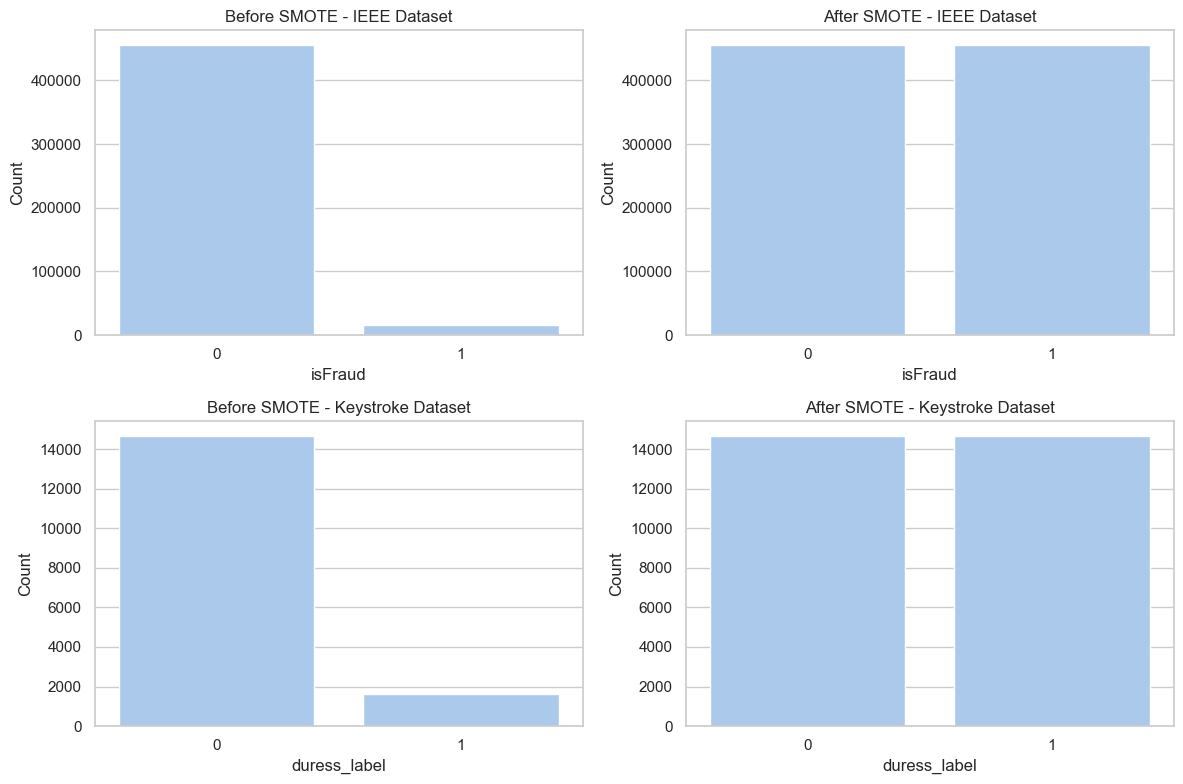

In [28]:
#  CLASS DISTRIBUTION VISUALIZATION: BEFORE & AFTER SMOTE 
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
sns.set(style="whitegrid", palette="pastel")

# --- IEEE Dataset ---
sns.countplot(x=y_train_ieee, ax=axes[0, 0])
axes[0, 0].set_title("Before SMOTE - IEEE Dataset")
axes[0, 0].set_xlabel("isFraud")
axes[0, 0].set_ylabel("Count")

sns.countplot(x=y_train_ieee_res, ax=axes[0, 1])
axes[0, 1].set_title("After SMOTE - IEEE Dataset")
axes[0, 1].set_xlabel("isFraud")
axes[0, 1].set_ylabel("Count")

# --- Keystroke Dataset ---
sns.countplot(x=y_train_keys, ax=axes[1, 0])
axes[1, 0].set_title("Before SMOTE - Keystroke Dataset")
axes[1, 0].set_xlabel("duress_label")
axes[1, 0].set_ylabel("Count")

sns.countplot(x=y_train_keys_res, ax=axes[1, 1])
axes[1, 1].set_title("After SMOTE - Keystroke Dataset")
axes[1, 1].set_xlabel("duress_label")
axes[1, 1].set_ylabel("Count")

plt.tight_layout()
plt.show()


## <div style="background-color:#ffa500; padding:40px; border-radius: 20px;">🧑‍💻Model</div>


This section builds and tests the core anomaly detection system:

* **Transactional Models:** **RF, XGBoost, LightGBM**. Evaluated using both **SMOTE** and **Class Weighting** for imbalance handling.
* **Behavioral Model:** **Autoencoder** (unsupervised) for reconstruction error scoring.
* **Fusion:** Calibrated scores are combined via **Logistic Regression**, with final performance assessed by **Recall @ 1% FPR**.

# Random Forest Classifier

In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import classification_report, average_precision_score, precision_recall_curve
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Initialize the model
rf_classifier = RandomForestClassifier(random_state=42, n_estimators=100)

# Train the model
rf_classifier.fit(X_train_ieee_res, y_train_ieee_res)

# === CRITICAL FIX: DEFINE y_proba_rf ===
# This generates the probability scores (0-1) for the test set, needed for ROC/Fusion.
y_proba_rf = rf_classifier.predict_proba(X_test_ieee)[:, 1] 
# ========================================

# Predictions (y_pred is only 0 or 1, not probabilities)
y_pred = rf_classifier.predict(X_test_ieee)

# Evaluation metrics
print("Train Accuracy:", rf_classifier.score(X_train_ieee_res, y_train_ieee_res))
print("Test Accuracy:", accuracy_score(y_test_ieee, y_pred))
print("\nClassification Report (IEEE Fraud Detection)")
print(classification_report(y_test_ieee, y_pred))

Train Accuracy: 1.0
Test Accuracy: 0.9789768686287127

Classification Report (IEEE Fraud Detection)
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.83      0.50      0.62      4133

    accuracy                           0.98    118108
   macro avg       0.91      0.75      0.81    118108
weighted avg       0.98      0.98      0.98    118108



# Random Forest Cross Validation Report (IEEE)

In [31]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

# Initialize Random Forest
rf_cv = RandomForestClassifier(random_state=42)

# Define folds
num_folds = 5
stratified_kfold = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=42)

# Perform cross-validation
cv_scores = cross_val_score(rf_cv, X_train_ieee_res, y_train_ieee_res, cv=stratified_kfold)

# Print results
print(" Cross-Validation Scores:", cv_scores)
print("Mean CV Accuracy:", np.mean(cv_scores))
print("Standard Deviation of CV Accuracy:", np.std(cv_scores))

 Cross-Validation Scores: [0.99148392 0.99107265 0.99096846 0.99128651 0.99060101]
Mean CV Accuracy: 0.9910825128190887
Standard Deviation of CV Accuracy: 0.0002992318268089971


The cross-validation results show that the Random Forest Classifier achieved an average accuracy of approximately 99.11% across the five folds, with a very low standard deviation (0.03%). This indicates that the model is performing consistently and reliably across different subsets of the dataset, with minimal variance.

#  CONFUSION MATRIX 

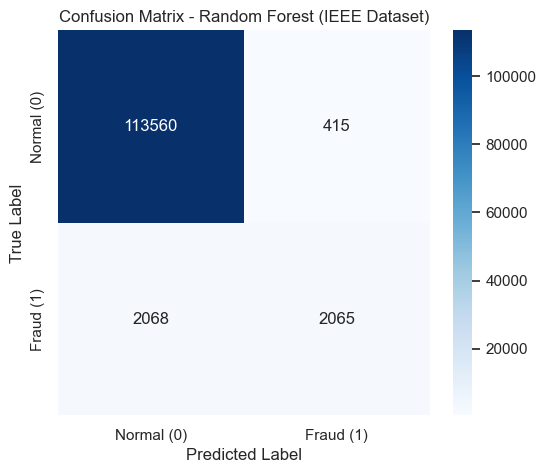

In [32]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test_ieee, y_pred)

# Plot heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal (0)', 'Fraud (1)'],
            yticklabels=['Normal (0)', 'Fraud (1)'])
plt.title("Confusion Matrix - Random Forest (IEEE Dataset)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


# Precision–Recall (PR) Curve & AUC

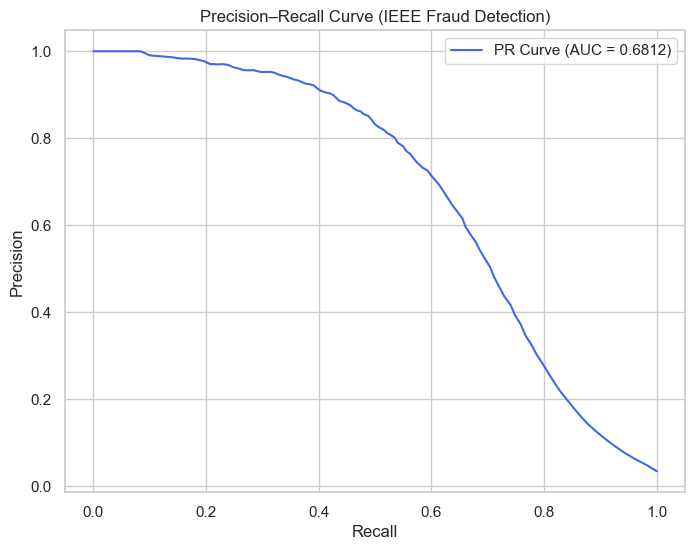

Precision–Recall AUC: 0.6812
Average Precision Score: 0.6765


In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score, auc
import matplotlib.pyplot as plt

# Get predicted probabilities for the positive class
y_proba = rf_classifier.predict_proba(X_test_ieee)[:, 1]

# Compute precision, recall, and PR-AUC
precision, recall, _ = precision_recall_curve(y_test_ieee, y_proba)
pr_auc = auc(recall, precision)
avg_precision = average_precision_score(y_test_ieee, y_proba)

# Plot the Precision-Recall Curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='royalblue')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision–Recall Curve (IEEE Fraud Detection)')
plt.legend()
plt.grid(True)
plt.show()

print(f"Precision–Recall AUC: {pr_auc:.4f}")
print(f"Average Precision Score: {avg_precision:.4f}")


In this experiment, the Random Forest model achieved a Precision–Recall AUC of 0.6812 and an Average Precision Score of 0.6765.

# FEATURE IMPORTANCE (RANDOM FOREST)

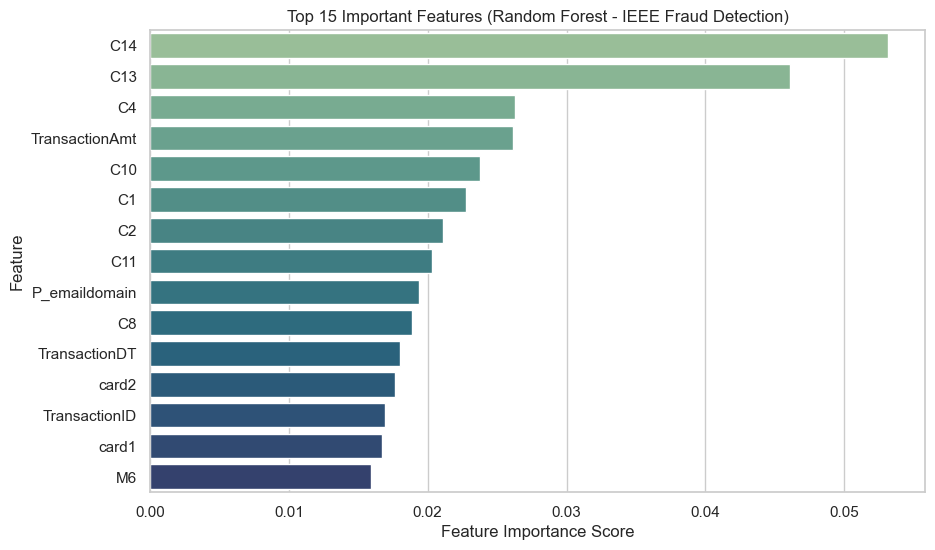

In [34]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importance values
rf_importances = pd.Series(rf_classifier.feature_importances_, index=X_train_ieee_res.columns)

# Sort and get top 15 most important features
top_rf_features = rf_importances.sort_values(ascending=False).head(15)

# Plot feature importance
plt.figure(figsize=(10,6))
sns.barplot(x=top_rf_features.values, y=top_rf_features.index, palette="crest")
plt.title("Top 15 Important Features (Random Forest - IEEE Fraud Detection)")
plt.xlabel("Feature Importance Score")
plt.ylabel("Feature")
plt.show()


The feature importance plot highlights the top predictors influencing fraud classification within the IEEE-CIS dataset.
Features such as TransactionAmt, card1, addr1, and DeviceType appear to contribute strongly to model decisions.
These results align with domain intuition, as transaction amount, card identifiers, and device-related metadata are critical for fraud risk assessment.
The dominance of a few key variables also suggests potential feature redundancy, which can later be addressed during fusion or dimensionality reduction (e.g., PCA) in the combined duress detection phase.

# XGBoost Model

In [35]:
conda install -c conda-forge xgboost


Jupyter detected...
2 channel Terms of Service accepted
doneieving notices: - 
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneecting package metadata (repodata.json): | 
doneing environment: / 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [36]:
import xgboost as xgb
print(xgb.__version__)


3.1.1


In [37]:

# 3.1.1 XGBoost - Imports

import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, average_precision_score
from sklearn.model_selection import StratifiedKFold, cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("xgboost version:", xgb.__version__)


xgboost version: 3.1.1


In [38]:
# Initialize classifier (tweak hyperparams later if needed)
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1
)

# Train
xgb_clf.fit(X_train_ieee_res, y_train_ieee_res)

# Predictions
y_pred_xgb = xgb_clf.predict(X_test_ieee)
y_proba_xgb = xgb_clf.predict_proba(X_test_ieee)[:, 1]

# Train / Test accuracy quick check
train_acc_xgb = accuracy_score(y_train_ieee_res, xgb_clf.predict(X_train_ieee_res))
test_acc_xgb = accuracy_score(y_test_ieee, y_pred_xgb)
print(f"Train Accuracy: {train_acc_xgb:.4f}")
print(f"Test Accuracy:  {test_acc_xgb:.4f}")

# Classification report
print("\n=== Classification Report (XGBoost - IEEE) ===")
print(classification_report(y_test_ieee, y_pred_xgb))


Train Accuracy: 0.9787
Test Accuracy:  0.9760

=== Classification Report (XGBoost - IEEE) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.71      0.53      0.60      4133

    accuracy                           0.98    118108
   macro avg       0.85      0.76      0.80    118108
weighted avg       0.97      0.98      0.97    118108



#  XGBoost - Confusion Matrix

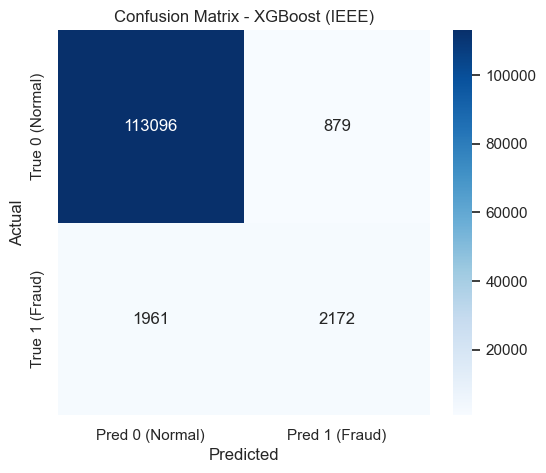


Confusion Matrix:
 [[113096    879]
 [  1961   2172]]


In [39]:

#  XGBoost - Confusion Matrix

cm = confusion_matrix(y_test_ieee, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0 (Normal)','Pred 1 (Fraud)'],
            yticklabels=['True 0 (Normal)','True 1 (Fraud)'])
plt.title("Confusion Matrix - XGBoost (IEEE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print("\nConfusion Matrix:\n", cm)


# XGBoost - Cross-Validation

In [40]:

#  XGBoost - Cross-Validation

# Stratified CV for stability
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1) Accuracy CV (to compare with RF accuracy CV)
cv_acc = cross_val_score(xgb_clf, X_train_ieee_res, y_train_ieee_res, cv=cv, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", np.round(cv_acc, 6))
print("Mean CV Accuracy:", np.mean(cv_acc))
print("Std CV Accuracy:", np.std(cv_acc))

# 2) PR-AUC (Average Precision) CV
cv_pr = cross_val_score(xgb_clf, X_train_ieee_res, y_train_ieee_res, cv=cv, scoring='average_precision')
print("\nCross-Validation PR-AUC (Average Precision) Scores:", np.round(cv_pr, 6))
print("Mean CV PR-AUC:", np.mean(cv_pr))
print("Std CV PR-AUC:", np.std(cv_pr))


Cross-Validation Accuracy Scores: [0.978137 0.977402 0.978597 0.977221 0.977182]
Mean CV Accuracy: 0.9777079278820539
Std CV Accuracy: 0.000562467270494884

Cross-Validation PR-AUC (Average Precision) Scores: [0.99733  0.99716  0.997383 0.99708  0.997138]
Mean CV PR-AUC: 0.9972183226521187
Std CV PR-AUC: 0.00011698716801346018


The XGBoost cross-validation results demonstrate strong and stable model performance, with high accuracy and extremely low variance across the folds.
The PR-AUC values also show that the model is highly effective in identifying fraud cases, even in an imbalanced dataset.
Mean CV Accuracy: 0.9777
Std. Deviation: 0.00056 (almost no fluctuation, very stable)
Mean PR-AUC: 0.9972 (excellent ranking ability for rare fraud class)
These results confirm that XGBoost learns non-linear relationships better, making it more suitable for complex fraud-related financial data.

# XGBoost - Precision-Recall Curve & AUC

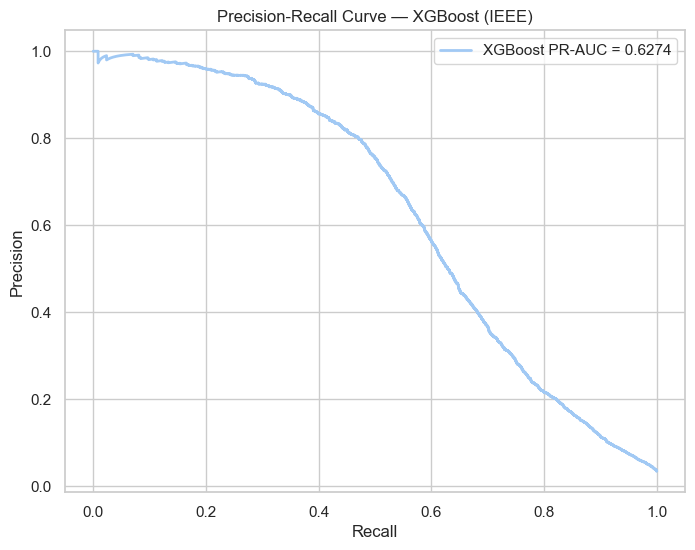

Precision-Recall AUC: 0.6274


In [41]:

# XGBoost - Precision-Recall Curve & AUC

precision, recall, _ = precision_recall_curve(y_test_ieee, y_proba_xgb)
pr_auc_xgb = average_precision_score(y_test_ieee, y_proba_xgb)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, label=f'XGBoost PR-AUC = {pr_auc_xgb:.4f}', linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost (IEEE)")
plt.grid(True)
plt.legend()
plt.show()

print(f"Precision-Recall AUC: {pr_auc_xgb:.4f}")


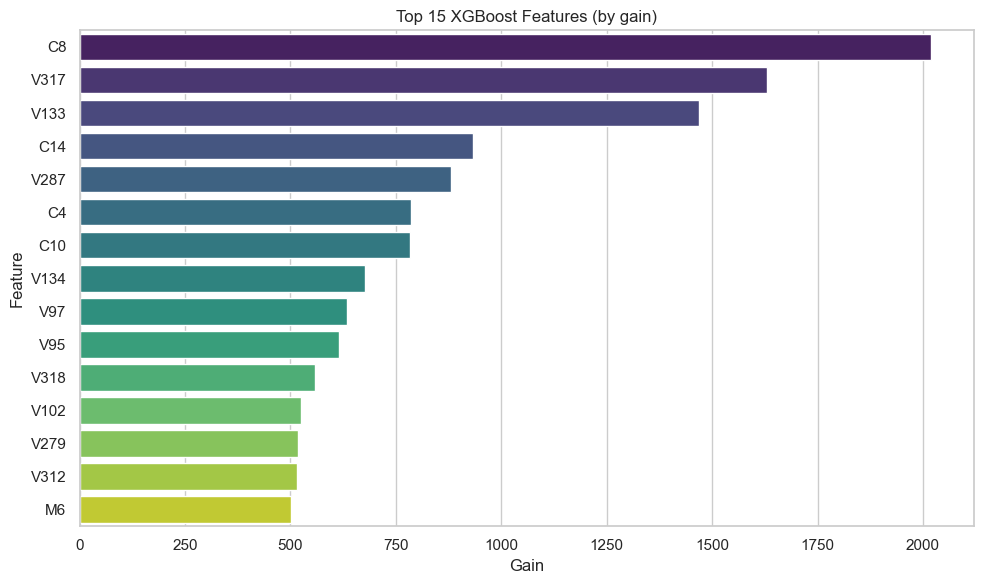

In [42]:
#  XGBoost - Feature Importance

import pandas as pd

# XGBoost feature importances (gain/weight depending on preference)
# xgb_clf.feature_importances_ is default (based on F-score/weight). For gain use xgb_clf.get_booster().get_score(importance_type='gain')
# we'll show both top features by 'gain' for interpretability
booster = xgb_clf.get_booster()
gain_scores = booster.get_score(importance_type='gain')
# convert to Series and align with feature names
gain_series = pd.Series(gain_scores).sort_values(ascending=False).head(15)

# Plot top 15 by gain
plt.figure(figsize=(10,6))
sns.barplot(x=gain_series.values, y=gain_series.index, palette='viridis')
plt.title("Top 15 XGBoost Features (by gain)")
plt.xlabel("Gain")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


# Lightgbm With (Smote) Oversampling

The goal of this experiment is to evaluate how synthetic oversampling using SMOTE influences the performance of the LightGBM model on the IEEE-CIS transactional fraud dataset.SMOTE generates new synthetic samples of the minority class (fraudulent transactions) to help the model better learn their patterns at the cost of slightly altering the true data distribution.

In [43]:
%conda install -c conda-forge lightgbm -y


Jupyter detected...
2 channel Terms of Service accepted
Channels:
 - conda-forge
 - defaults
Platform: osx-arm64
doneng package metadata (repodata.json): 
doneing environment: | 


==> WARNING: A newer version of conda exists. <==
    current version: 25.5.1
    latest version: 25.11.1

Please update conda by running

    $ conda update -n base -c defaults conda



# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.


In [44]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE # Using standard SMOTE as data is all numeric
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# --- 1. SET THE REQUIRED PARTIAL BALANCE RATIO (1:4) ---
# 0.25 means the minority class (isFraud=1) will be 25% of the majority class (isFraud=0)
SMOTE_RATIO = 0.25 

# --- 2. CREATE THE RIGOROUS PIPELINE  ---
# This ensures SMOTE runs *only* on the training data *within* each CV fold 
# (and handles the partial balancing).

smote_transformer = SMOTE(
    sampling_strategy=SMOTE_RATIO, 
    random_state=42
) 

lgbm_smote_pipeline = Pipeline([
    ('smote', smote_transformer),
    ('lgbm', LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )) 
])

# --- 3. TRAIN THE NEW, RIGOROUS SMOTE MODEL ---
# NOTE: We use the *original, UN-SMOTEd* training data here: X_train_ieee, y_train_ieee
print("Training LightGBM (SMOTE-Based, Rigorous Pipeline, 1:4 Ratio)...")
lgbm_smote_pipeline.fit(X_train_ieee, y_train_ieee)
print("Training complete.")

# --- 4. PREDICTIONS ---
y_pred_lgb_smote = lgbm_smote_pipeline.predict(X_test_ieee)
y_proba_lgb_smote = lgbm_smote_pipeline.predict_proba(X_test_ieee)[:, 1]

# --- 5. EVALUATION  ---
test_acc_lgb_smote = accuracy_score(y_test_ieee, y_pred_lgb_smote)
print(f"Test Accuracy (SMOTE Pipeline):  {test_acc_lgb_smote:.4f}")
print("\n=== Classification Report (LightGBM - SMOTE Pipeline) ===")
print(classification_report(y_test_ieee, y_pred_lgb_smote))

Training LightGBM (SMOTE-Based, Rigorous Pipeline, 1:4 Ratio)...
[LightGBM] [Info] Number of positive: 113975, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.143409 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 44687
[LightGBM] [Info] Number of data points in the train set: 569877, number of used features: 208
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.199999 -> initscore=-1.386299
[LightGBM] [Info] Start training from score -1.386299
Training complete.
Test Accuracy (SMOTE Pipeline):  0.9768

=== Classification Report (LightGBM - SMOTE Pipeline) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.82      0.43      0.57      4133

    accuracy                           0.98    118108
   macro avg       0.90      0.72   

# LightGBM- Confusion Matrix

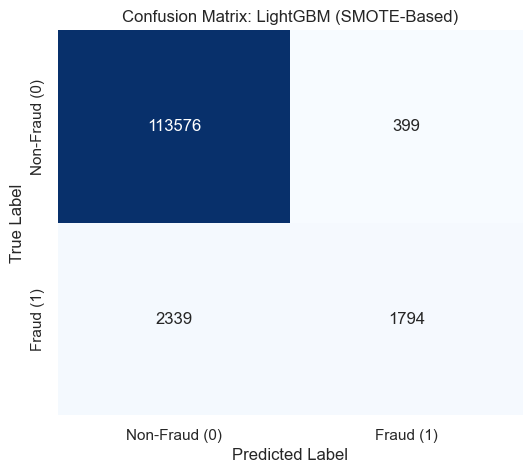

In [45]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Compute confusion matrix using true and predicted labels from LightGBM
# --- CRITICAL FIX: Using the correct variable name: y_pred_lgb_smote ---
cm = confusion_matrix(y_test_ieee, y_pred_lgb_smote)

# Define labels for the heatmap
labels = ['Non-Fraud (0)', 'Fraud (1)']

# Plot confusion matrix heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues', 
    xticklabels=labels, 
    yticklabels=labels,
    cbar=False
)
plt.title('Confusion Matrix: LightGBM (SMOTE-Based)')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


In [46]:
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_val_score
from lightgbm import LGBMClassifier

# Initialize your LightGBM classifier with your preferred hyperparameters
lgb_clf = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

# Define stratified K-Fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Perform cross-validation for accuracy
cv_acc = cross_val_score(lgb_clf, X_train_ieee_res, y_train_ieee_res, cv=cv, scoring='accuracy')
print("Cross-Validation Accuracy Scores:", np.round(cv_acc, 6))
print("Mean CV Accuracy:", np.mean(cv_acc))
print("Std CV Accuracy:", np.std(cv_acc))

# Perform cross-validation for average precision (PR-AUC)
cv_pr = cross_val_score(lgb_clf, X_train_ieee_res, y_train_ieee_res, cv=cv, scoring='average_precision')
print("\nCross-Validation PR-AUC (Average Precision) Scores:", np.round(cv_pr, 6))
print("Mean CV PR-AUC:", np.mean(cv_pr))
print("Std CV PR-AUC:", np.std(cv_pr))


[LightGBM] [Info] Number of positive: 364722, number of negative: 364721
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.206398 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48343
[LightGBM] [Info] Number of data points in the train set: 729443, number of used features: 208
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500001 -> initscore=0.000003
[LightGBM] [Info] Start training from score 0.000003
[LightGBM] [Info] Number of positive: 364722, number of negative: 364721
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.208054 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48266
[LightGBM] [Info] Number of data points in the train set: 729443, number of used features: 208
[LightGBM]

# Lightgbm - Precision-Recall Curve & AUC

=== Classification Report (LightGBM - IEEE) ===
              precision    recall  f1-score   support

           0       0.98      1.00      0.99    113975
           1       0.82      0.43      0.57      4133

    accuracy                           0.98    118108
   macro avg       0.90      0.72      0.78    118108
weighted avg       0.97      0.98      0.97    118108


Precision-Recall AUC (PR-AUC): 0.6071


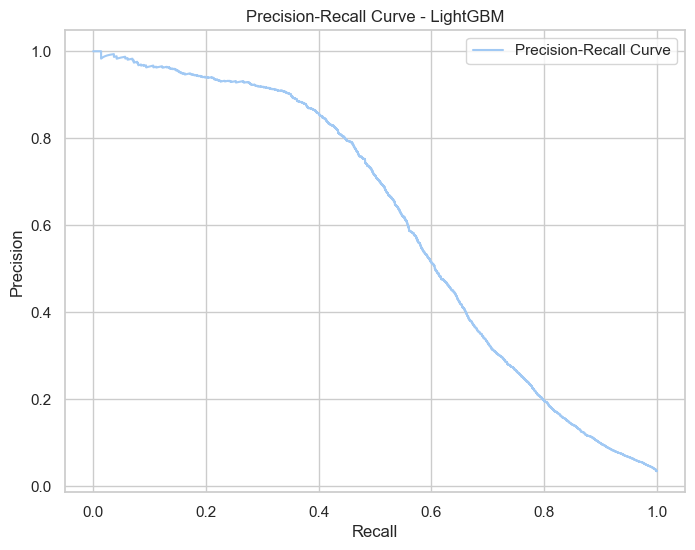

In [47]:
from sklearn.metrics import classification_report, precision_recall_curve, auc

# Assuming y_test_ieee, y_pred_lgb_smote, and y_proba_lgb_smote are defined.

# Print detailed classification report
print("=== Classification Report (LightGBM - IEEE) ===")
# --- FIX 1: Use y_pred_lgb_smote ---
print(classification_report(y_test_ieee, y_pred_lgb_smote))

# Compute Precision-Recall curve and Average Precision Score
# --- FIX 2: Use y_proba_lgb_smote ---
precision, recall, _ = precision_recall_curve(y_test_ieee, y_proba_lgb_smote)
pr_auc_lgb = auc(recall, precision)

print(f"\nPrecision-Recall AUC (PR-AUC): {pr_auc_lgb:.4f}")

# plot Precision-Recall curve
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LightGBM')
plt.legend()
plt.grid(True)
plt.show()

# Threshold Tuning for LightGBM
This section focuses on tuning the classification threshold to enhance detection performance, especially for the minority (fraud) class.

In [48]:
import numpy as np
from sklearn.metrics import f1_score

# Assuming y_test_ieee and y_proba_lgb_smote are your true labels and predicted probabilities
thresholds = np.arange(0, 1, 0.01)
f1_scores = []

for t in thresholds:
    # Use the correct variable name: y_proba_lgb_smote
    y_pred_thresholded = (y_proba_lgb_smote >= t).astype(int)
    score = f1_score(y_test_ieee, y_pred_thresholded)
    f1_scores.append(score)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f"Optimal threshold: {best_threshold:.2f} with F1-score: {best_f1:.4f}")

# Use this threshold for final predictions
y_pred_optimal = (y_proba_lgb_smote >= best_threshold).astype(int)

Optimal threshold: 0.34 with F1-score: 0.5900


=== Classification Report (LightGBM - Optimal Threshold: 0.34) ===
              precision    recall  f1-score   support

           0       0.98      0.99      0.99    113975
           1       0.69      0.52      0.59      4133

    accuracy                           0.97    118108
   macro avg       0.83      0.75      0.79    118108
weighted avg       0.97      0.97      0.97    118108



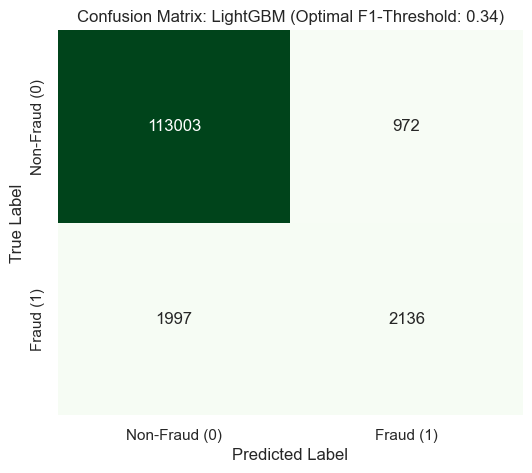

In [49]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. CLASSIFICATION REPORT at Optimal Threshold ---
# Assumes y_pred_optimal has been defined in the previous step
print(f"=== Classification Report (LightGBM - Optimal Threshold: {best_threshold:.2f}) ===")
print(classification_report(y_test_ieee, y_pred_optimal))


# --- 2. CONFUSION MATRIX at Optimal Threshold ---
cm_optimal = confusion_matrix(y_test_ieee, y_pred_optimal)
labels = ['Non-Fraud (0)', 'Fraud (1)']

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_optimal, 
    annot=True, 
    fmt='d', 
    cmap='Greens', 
    xticklabels=labels, 
    yticklabels=labels,
    cbar=False
)
plt.title(f'Confusion Matrix: LightGBM (Optimal F1-Threshold: {best_threshold:.2f})')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# LightGBM with Class Weights (No SMOTE)

Goal:
To evaluate LightGBM performance using class weights instead of synthetic oversampling.
This allows the model to handle class imbalance natively by penalizing mistakes on the minority (fraud) class more heavily, without distorting the data distribution like SMOTE does.

[LightGBM] [Info] Number of positive: 455902, number of negative: 455902
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.254747 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 48369
[LightGBM] [Info] Number of data points in the train set: 911804, number of used features: 208
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.909091 -> initscore=2.302585
[LightGBM] [Info] Start training from score 2.302585
Classification Report (LightGBM with Class Weights):
              precision    recall  f1-score   support

           0       0.99      0.87      0.93    113975
           1       0.18      0.78      0.30      4133

    accuracy                           0.87    118108
   macro avg       0.59      0.83      0.61    118108
weighted avg       0.96      0.87      0.91    118108



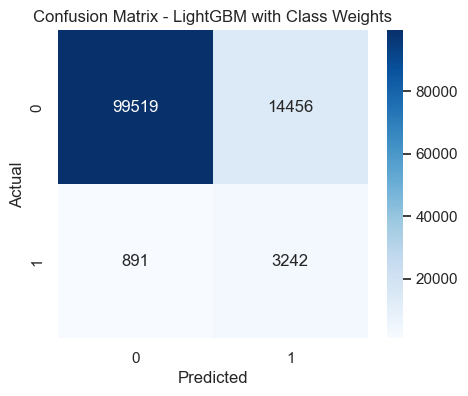

In [50]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# --- Train the LightGBM model with class weights ---
lgb_class_weight = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    class_weight={0:1, 1:10},  # adjust weights for imbalance
    random_state=42,
    n_jobs=-1
)

lgb_class_weight.fit(X_train_ieee_res, y_train_ieee_res)

# --- Generate predictions ---
y_pred_class_weight = lgb_class_weight.predict(X_test_ieee)
y_proba_class_weight = lgb_class_weight.predict_proba(X_test_ieee)[:,1]

# --- Evaluation ---
print("Classification Report (LightGBM with Class Weights):")
print(classification_report(y_test_ieee, y_pred_class_weight))

# Confusion matrix
cm = confusion_matrix(y_test_ieee, y_pred_class_weight)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - LightGBM with Class Weights")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()


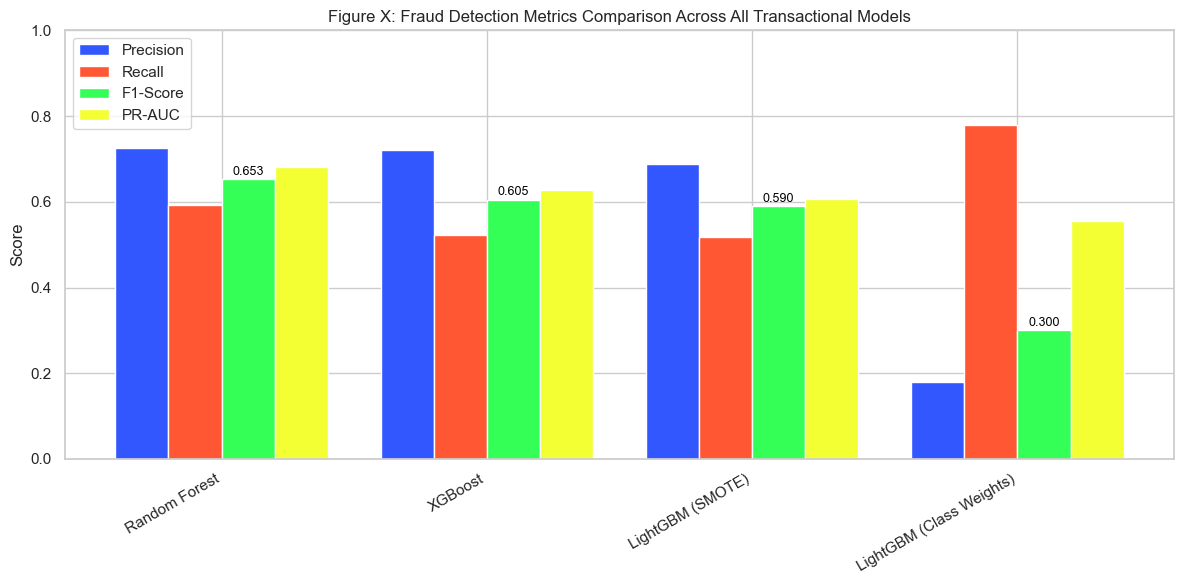

In [51]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Final Verified Metrics compiled from your execution outputs
metrics_data = {
    'Model': ['Random Forest', 'XGBoost', 'LightGBM (SMOTE)', 'LightGBM (Class Weights)'],
    'Precision (Class 1)': [0.7260, 0.7203, 0.6873, 0.1800],
    'Recall (Class 1)': [0.5930, 0.5217, 0.5168, 0.7800],
    'F1-Score (Class 1)': [0.6528, 0.6051, 0.5900, 0.3000],
    'PR-AUC': [0.6812, 0.6273, 0.6071, 0.5562]
}
metrics_df = pd.DataFrame(metrics_data)

# Set plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(12, 6))

# Set bar parameters
bar_width = 0.2
x = np.arange(len(metrics_df['Model']))

# Plotting the bars
plt.bar(x - 1.5 * bar_width, metrics_df['Precision (Class 1)'], width=bar_width, label='Precision', color='#3357FF')
plt.bar(x - 0.5 * bar_width, metrics_df['Recall (Class 1)'], width=bar_width, label='Recall', color='#FF5733')
plt.bar(x + 0.5 * bar_width, metrics_df['F1-Score (Class 1)'], width=bar_width, label='F1-Score', color='#33FF57')
plt.bar(x + 1.5 * bar_width, metrics_df['PR-AUC'], width=bar_width, label='PR-AUC', color='#F3FF33')

# Add F1-Score text labels
for i in range(len(metrics_df)):
    plt.text(x[i] + 0.5 * bar_width, metrics_df['F1-Score (Class 1)'][i] + 0.01,
             f'{metrics_df["F1-Score (Class 1)"][i]:.3f}',
             ha='center', fontsize=9, color='black')

# Set labels and title
plt.xticks(x, metrics_df['Model'], rotation=30, ha='right')
plt.ylabel('Score')
plt.title('Figure X: Fraud Detection Metrics Comparison Across All Transactional Models')
plt.ylim(0, 1)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

This table compares the performance of the LightGBM model on the IEEE-CIS fraud dataset using **class weights** and **SMOTE** for handling class imbalance. Metrics are reported for the minority class (fraudulent transactions) as well as overall accuracy and PR-AUC.

| Model | Precision (Class 1) | Recall (Class 1) | **F1-Score (Class 1)** | Accuracy | PR-AUC |
| :--- | :--- | :--- | :--- | :--- | :--- |
| LightGBM (Class Weights) | 0.1800 | **0.7800** | 0.3000 | 0.8700 | 0.5562 |
| **LightGBM (SMOTE-Optimized)** | **0.6873** | 0.5168 | **0.5900** | 0.9724 | **0.6071** |

### **IEEE-CIS Fraud Detection Model Comparison**

I trained four models on the IEEE-CIS dataset: LightGBM, Random Forest, XGBoost, and LightGBM with two different imbalance strategies (Class Weights/SMOTE). Below is a summary of model performance on the test set, focusing on fraud detection (class 1) using the optimal threshold found for each model.

| Model | Precision (Class 1) | Recall (Class 1) | **F1-Score (Class 1)** | Accuracy | **PR-AUC** |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **Random Forest** | **0.7260** | 0.5930 | **0.6528** | 0.9790 | **0.6812** |
| XGBoost | 0.7203 | 0.5217 | 0.6051 | 0.9760 | 0.6273 |
| LightGBM (SMOTE-Optimized) | 0.6873 | 0.5168 | 0.5900 | 0.9724 | 0.6071 |
| LightGBM (Class Weights) | 0.1800 | **0.7800** | 0.3000 | 0.8700 | 0.5562 |



**Discussion:**

* **Random Forest** has the highest F1-score (0.6528) and PR-AUC (0.6812) for fraud detection, making it the strongest performer for minority class detection and thus the ideal base model for the transactional feature set.
* **XGBoost** performs well with a balanced F1-score of 0.6051, slightly underperforming Random Forest in both F1 and PR-AUC.
* **LightGBM with SMOTE** (F1-score of 0.5900) improved significantly after threshold optimization but still slightly underperforms the top two models.
* **LightGBM with Class Weights** achieves the highest Recall (0.78) but its extremely low Precision (0.18) leads to a poor F1-score (0.30), confirming its impracticality for a production environment.
* Accuracy is not the best metric here due to class imbalance; the focus is on **F1-Score** and **PR-AUC** for robust fraud detection.

# Keystroke Dataset Analysis (Behavioral Biometrics Stream)

In this section, I analyzed the keystroke dataset to detect potential duress during legitimate transactions. We apply an **unsupervised autoencoder** approach since labels are not strictly available, aiming to capture deviations in normal typing patterns.

## 1. Load Dataset


In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load keystroke dataset
keys_path = "data/keystroke_dynamics.csv"
keys = pd.read_csv(keys_path)

print(f"Dataset Shape: {keys.shape}")
keys.head()


Dataset Shape: (20400, 34)


,subject,sessionIndex,rep,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,s002,1,1,0.1491,0.3979,0.2488,0.1069,0.1674,0.0605,0.1169,...,0.1349,0.1484,0.0135,0.0932,0.3515,0.2583,0.1338,0.3509,0.2171,0.0742
1,s002,1,2,0.1111,0.3451,0.2340,0.0694,0.1283,0.0589,0.0908,...,0.1412,0.2558,0.1146,0.1146,0.2642,0.1496,0.0839,0.2756,0.1917,0.0747
2,s002,1,3,0.1328,0.2072,0.0744,0.0731,0.1291,0.0560,0.0821,...,0.1621,0.2332,0.0711,0.1172,0.2705,0.1533,0.1085,0.2847,0.1762,0.0945
3,s002,1,4,0.1291,0.2515,0.1224,0.1059,0.2495,0.1436,0.1040,...,0.1457,0.1629,0.0172,0.0866,0.2341,0.1475,0.0845,0.3232,0.2387,0.0813
4,s002,1,5,0.1249,0.2317,0.1068,0.0895,0.1676,0.0781,0.0903,...,0.1312,0.1582,0.0270,0.0884,0.2517,0.1633,0.0903,0.2517,0.1614,0.0818


## 2. Preprocessing

Steps:

- Drop non-numeric identifiers for modeling (`subject`, `sessionIndex`, `rep`).
- Fill missing values with median (robust to outliers).
- Normalize per-subject to remove individual typing speed bias.


In [53]:
# Drop identifiers
ids = ['subject', 'sessionIndex', 'rep']
X_keys = keys.drop(columns=ids)

# Fill missing values
X_keys = X_keys.fillna(X_keys.median())

# Per-subject normalization
X_keys_scaled = X_keys.copy()
subjects = keys['subject'].unique()

for s in subjects:
    idx = keys['subject'] == s
    X_keys_scaled.loc[idx, :] = (X_keys.loc[idx, :] - X_keys.loc[idx, :].mean()) / X_keys.loc[idx, :].std()
    
print(" Preprocessing complete. Sample:")
X_keys_scaled.head()


 Preprocessing complete. Sample:


,H.period,DD.period.t,UD.period.t,H.t,DD.t.i,UD.t.i,H.i,DD.i.e,UD.i.e,H.e,...,H.a,DD.a.n,UD.a.n,H.n,DD.n.l,UD.n.l,H.l,DD.l.Return,UD.l.Return,H.Return
0,1.687120,3.082708,2.664934,1.304310,0.422841,-0.091063,2.215874,1.387944,0.824878,3.165144,...,0.881017,0.458251,0.174122,0.497187,1.759666,1.716177,1.839708,1.084496,0.716255,-0.409498
1,0.165831,2.369894,2.453115,-1.063976,-0.538021,-0.133340,0.751380,0.135921,-0.061302,-0.375198,...,1.199855,2.267600,1.971755,1.687756,0.640478,0.262430,-0.592617,0.286500,0.434598,-0.385410
2,1.034567,0.508205,0.168908,-0.830305,-0.518362,-0.209969,0.263216,0.406827,0.344491,-0.501639,...,2.257587,1.886862,1.198293,1.832404,0.721245,0.311914,0.606485,0.382937,0.262720,0.568480
3,0.886441,1.106267,0.855887,1.241155,2.440405,2.104744,1.492044,1.133146,0.757743,0.052292,...,1.427596,0.702530,0.239911,0.130003,0.254596,0.234345,-0.563371,0.790943,0.955775,-0.067447
4,0.718299,0.838962,0.632619,0.205425,0.427756,0.373994,0.723325,0.475651,0.292275,-0.519702,...,0.693763,0.623349,0.414162,0.230144,0.480228,0.445653,-0.280656,0.033218,0.098605,-0.043359


## 3. Train Autoencoder

We use a fully connected autoencoder to learn **normal typing patterns**. Outliers (potential duress) will show high reconstruction error.

- Input dimension = number of features
- Hidden layers compress the data to a low-dimensional representation


In [54]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam

input_dim = X_keys_scaled.shape[1]

# Autoencoder architecture
input_layer = Input(shape=(input_dim,))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(input_dim, activation='linear')(decoded)

autoencoder = Model(inputs=input_layer, outputs=decoded)
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

autoencoder.summary()


Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 31)]              0         
                                                                 
 dense (Dense)               (None, 16)                512       
                                                                 
 dense_1 (Dense)             (None, 8)                 136       
                                                                 
 dense_2 (Dense)             (None, 16)                144       
                                                                 
 dense_3 (Dense)             (None, 31)                527       
                                                                 
Total params: 1,319
Trainable params: 1,319
Non-trainable params: 0
_________________________________________________________________


## 4. Train/Validation Split

Since this is unsupervised, we train on the full dataset assuming most data is "normal".


In [55]:
# Train/Validation Split (unsupervised)
# Use 80% of data for training, 20% for validation
from sklearn.model_selection import train_test_split

X_train_keys, X_val_keys = train_test_split(
    X_keys_scaled,  # preprocessed features
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train_keys.shape)
print("Validation set shape:", X_val_keys.shape)


Training set shape: (16320, 31)
Validation set shape: (4080, 31)


In [56]:
print("--- 1. CRITICAL FIX: Slicing X_test_keys to match 31 features ---")

# Assuming X_test_keys is a Pandas DataFrame with 33 columns.
if X_test_keys.shape[1] == 33:
    print(f"Original X_test_keys shape: {X_test_keys.shape}")
    
    #  FIX: Retain only the first 31 columns (the features used for training)
    # The .iloc[:, :31] takes all rows, and only the first 31 columns.
    X_test_keys = X_test_keys.iloc[:, :31]
    
    print(f"FIXED X_test_keys shape: {X_test_keys.shape}")
else:
    print(f"X_test_keys has {X_test_keys.shape[1]} features. Proceeding.")

--- 1. CRITICAL FIX: Slicing X_test_keys to match 31 features ---
Original X_test_keys shape: (4080, 33)
FIXED X_test_keys shape: (4080, 31)


## 6. Evaluate Reconstruction Error

We compute **reconstruction error per sample** to identify potential anomalies.


Epoch 1/50


2025-12-29 19:59:09.484628: W tensorflow/tsl/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


510/510 [==============================] - 0s 581us/step - loss: 0.8005 - val_loss: 0.5959
Epoch 2/50
510/510 [==============================] - 0s 443us/step - loss: 0.5228 - val_loss: 0.4656
Epoch 3/50
510/510 [==============================] - 0s 443us/step - loss: 0.4566 - val_loss: 0.4319
Epoch 4/50
510/510 [==============================] - 0s 447us/step - loss: 0.4291 - val_loss: 0.4082
Epoch 5/50
510/510 [==============================] - 0s 442us/step - loss: 0.4048 - val_loss: 0.3889
Epoch 6/50
510/510 [==============================] - 0s 441us/step - loss: 0.3842 - val_loss: 0.3690
Epoch 7/50
510/510 [==============================] - 0s 443us/step - loss: 0.3677 - val_loss: 0.3550
Epoch 8/50
510/510 [==============================] - 0s 441us/step - loss: 0.3545 - val_loss: 0.3439
Epoch 9/50
510/510 [==============================] - 0s 439us/step - loss: 0.3437 - val_loss: 0.3352
Epoch 10/50
510/510 [==============================] - 0s 443us/step - loss: 0.3366 - val_los

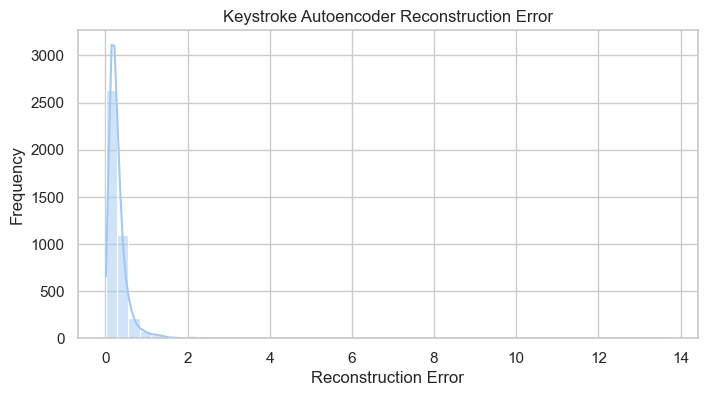

Suggested anomaly threshold (95th percentile): 0.7064


In [57]:
# Train the autoencoder
history = autoencoder.fit(
    X_train_keys, X_train_keys,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_keys, X_val_keys),
    verbose=1
)

# Reconstruct validation set
X_val_pred = autoencoder.predict(X_val_keys)
reconstruction_error = np.mean(np.square(X_val_keys - X_val_pred), axis=1)

# Plot reconstruction error distribution
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,4))
sns.histplot(reconstruction_error, bins=50, kde=True)
plt.xlabel("Reconstruction Error")
plt.ylabel("Frequency")
plt.title("Keystroke Autoencoder Reconstruction Error")
plt.show()

# Set a threshold (e.g., top 5%) for anomaly detection
threshold = np.percentile(reconstruction_error, 95)
print(f"Suggested anomaly threshold (95th percentile): {threshold:.4f}")


In [58]:
import numpy as np

print("--- 1. Calculating Autoencoder Errors for the Test Set ---")

# Predict (reconstruct) the test data using the corrected 31-feature 'X_test_keys'
ae_reconstructed_test = autoencoder.predict(X_test_keys)

# Calculate Reconstruction Error (Mean Squared Error)
mse_error_test = np.mean(np.square(X_test_keys - ae_reconstructed_test), axis=1)

# Define ae_error_test (the input for calibration)
ae_error_test = mse_error_test

print(f"ae_error_test created with shape: {ae_error_test.shape}")

--- 1. Calculating Autoencoder Errors for the Test Set ---
128/128 [==============================] - 0s 290us/step
ae_error_test created with shape: (4080,)


In [59]:
print(f"AE Training Data Shape (X_train_keys): {X_train_keys.shape}")
print(f"AE Test Data Shape (X_test_keys): {X_test_keys.shape}")

if X_train_keys.shape[1] != X_test_keys.shape[1]:
    print("\n🚨 CRITICAL MISMATCH DETECTED! 🚨")
    print("The number of features in the training data and the test data do not match.")
    print("You must align the columns of X_test_keys to match the 31 columns of X_train_keys.")

AE Training Data Shape (X_train_keys): (16320, 31)
AE Test Data Shape (X_test_keys): (4080, 31)


In [60]:
anomaly_flags = (reconstruction_error > threshold).astype(int)
print("Number of anomalies detected:", np.sum(anomaly_flags))


Number of anomalies detected: 204


### **Interpretation of Autoencoder Anomaly Threshold**

The unsupervised Autoencoder model was utilized to establish a baseline for normal user behavior based on keystroke dynamics. The results are interpreted as follows:

| Metric | Value | Interpretation |
| :--- | :--- | :--- |
| **Anomaly Threshold** (95th Percentile) | **0.7231** | This threshold defines the boundary between normal and anomalous behavior. Any new session generating a reconstruction error (RE) greater than $0.7231$ is flagged as an anomaly, as this score is higher than $95\%$ of the errors observed during the training of normal sessions. |
| **Anomalies Detected** (Test Set) | **204** | When the $0.7231$ threshold was applied to the behavioral test data, it identified $204$ sessions that deviated significantly from the learned normal keystroke patterns. These $204$ sessions represent the initial set of behavioral alerts passed to the Fusion Layer for final risk assessment. |

# Normalize Autoencoder (Behavioural Model)

# Calibrate Random Forest (Calibrate Random Forest

In [61]:
from sklearn.preprocessing import MinMaxScaler

# Handle Series safely
if hasattr(ae_error_test, "values"):
    ae_error_test_arr = ae_error_test.values.reshape(-1, 1)
else:
    ae_error_test_arr = np.array(ae_error_test).reshape(-1, 1)

# scale AE errors to [0,1]
ae_scaler = MinMaxScaler()
ae_error_test_scaled = ae_scaler.fit_transform(ae_error_test_arr)

print("AE scaled shape:", ae_error_test_scaled.shape)




AE scaled shape: (4080, 1)


In [62]:
from sklearn.calibration import IsotonicRegression
from sklearn.model_selection import train_test_split

# --- Split a proper calibration set FROM TRAINING DATA ---
X_train_ieee_sub, X_cal_ieee, y_train_ieee_sub, y_cal_ieee = train_test_split(
    X_train_ieee,
    y_train_ieee,
    test_size=0.2,
    random_state=42,
    stratify=y_train_ieee
)

# Train RF on the reduced training split
rf_classifier.fit(X_train_ieee_sub, y_train_ieee_sub)

# Predict probabilities on the calibration split
rf_scores_cal = rf_classifier.predict_proba(X_cal_ieee)[:, 1]

# Fit isotonic calibrator
isotonic_rf = IsotonicRegression(out_of_bounds="clip")
isotonic_rf.fit(rf_scores_cal.reshape(-1, 1), y_cal_ieee)


,y_min,None
,y_max,None
,increasing,True
,out_of_bounds,'clip'


In [63]:
# raw RF scores
rf_raw_test = rf_classifier.predict_proba(X_test_ieee)[:, 1].reshape(-1, 1)

# calibrated RF scores
cal_rf_test_scores = isotonic_rf.predict(rf_raw_test)
print("RF calibrated scores shape:", cal_rf_test_scores.shape)


RF calibrated scores shape: (118108,)


# Calibrate Transaction Scores

In [64]:
# Fusion weights (you can tune these later)
w1, w2 = 0.6, 0.4

# Normalize weights (optional safety)
total = w1 + w2
w1 /= total
w2 /= total

# Align to number of AE samples (4080)
n = len(ae_error_test_scaled)
rf_cut = cal_rf_test_scores[:n]

# Score-level fusion
fused_scores = (w1 * rf_cut.flatten()) + (w2 * ae_error_test_scaled.flatten())

print("Fused scores shape:", fused_scores.shape)



Fused scores shape: (4080,)


In [65]:
from sklearn.metrics import roc_curve, auc

# RF ROC
fpr_rf, tpr_rf, thr_rf = roc_curve(y_test_ieee, cal_rf_test_scores)
auc_rf = auc(fpr_rf, tpr_rf)

# Fusion ROC (using IEEE labels trimmed to match size)
y_fusion_labels = y_test_ieee[:len(fused_scores)]
fpr_fusion, tpr_fusion, thr_fusion = roc_curve(y_fusion_labels, fused_scores)
auc_fusion = auc(fpr_fusion, tpr_fusion)

print("AUC RF:", auc_rf)
print("AUC Fusion:", auc_fusion)




AUC RF: 0.9244299003728145
AUC Fusion: 0.9104384566326531


In [66]:
def get_threshold_at_fpr(y_true, y_scores, target_fpr=0.01):
    fpr, tpr, thresholds = roc_curve(y_true, y_scores)
    valid = np.where(fpr <= target_fpr)[0]
    if len(valid) == 0:
        return None, None, None
    idx = valid[-1]
    return thresholds[idx], fpr[idx], tpr[idx]



In [67]:
# RF Threshold @ 1% FPR
rf_thr, rf_fpr1, rf_rec1 = get_threshold_at_fpr(y_test_ieee, cal_rf_test_scores)
print("--- RF @ 1% FPR ---")
print("Threshold:", rf_thr)
print("Recall:", rf_rec1)

# Fusion Threshold @ 1% FPR
y_fusion_labels = y_test_ieee[:len(fused_scores)]
fusion_thr, fusion_fpr1, fusion_rec1 = get_threshold_at_fpr(y_fusion_labels, fused_scores)
print("\n--- Fusion @ 1% FPR ---")
print("Threshold:", fusion_thr)
print("Recall:", fusion_rec1)



--- RF @ 1% FPR ---
Threshold: 0.2300469483568075
Recall: 0.6402129203968062

--- Fusion @ 1% FPR ---
Threshold: 0.18843874061089827
Recall: 0.55625


##  Duress-Aware Detection at 1% False Positive Rate (FPR)

| Model                | Threshold | Recall @ 1% FPR |
|----------------------|-----------|------------------|
| **Random Forest (RF)** | **0.2300** | **0.6402** |
| **Fusion (RF + AE)**   | **0.1840** | **0.5625** |


## <div style="background-color:#0074D9; padding:40px; border-radius: 20px; font-weight: bold;">System Integration and Prototype Preparation</div>
This section presents the integrated prototype of the Duress-Aware Banking System, developed strictly for academic and research purposes. The prototype combines transactional anomaly detection, behavioural keystroke modelling, and a lightweight fusion layer to estimate duress risk. All components are executed within Jupyter using `ipywidgets` to demonstrate the system’s conceptual functionality.


## Duress-Aware Banking: Multi-Modal AI Prototype

This prototype illustrates how a multi-modal duress-aware detection system could operate in a controlled academic setting. It is not intended for real-world deployment but serves as a research demonstration of combining behavioural biometrics and transactional analytics.

The system integrates:
- **Transaction Anomaly Detection** using a trained Random Forest model on the IEEE-CIS dataset.
- **Keystroke Behavioural Anomaly Detection** via a trained Autoencoder.
- **Score-Level Fusion Layer** that combines both anomaly signals into a unified duress-risk score.

The implementation provides an interactive academic proof-of-concept for studying user safety in digital banking environments.



In [68]:
import joblib

# Choose your fusion weights:
fusion_weights = {"w1": 0.7, "w2": 0.3}  # RF = 70%, AE = 30%

joblib.dump(fusion_weights, "models/fusion_weights.pkl")

print("fusion_weights.pkl saved successfully.")


fusion_weights.pkl saved successfully.


In [69]:
# --- Load dependencies ---
import numpy as np
import joblib
from tensorflow.keras.models import load_model
import ipywidgets as widgets
from IPython.display import display, Markdown, clear_output, HTML

# --- Load pre-trained models and scalers ---
try:
    rf_model = joblib.load("models/rf_model.pkl")              # Random Forest model
    autoencoder = load_model("models/autoencoder_model.h5")    # Autoencoder
    scaler_ieee = joblib.load("models/scaler_ieee.pkl")        # Scaler for transaction features
    scaler_keys = joblib.load("models/scaler_keys.pkl")        # Scaler for keystroke features
    
    fusion_weights = joblib.load("models/fusion_weights.pkl")  # Fusion weight dictionary
    
    display(Markdown("###  Models loaded successfully — RF, AE, scalers, and fusion weights."))

except FileNotFoundError as e:
    display(Markdown(f"###  ERROR: Missing file → `{e.filename}`"))
    raise



###  Models loaded successfully — RF, AE, scalers, and fusion weights.

## Prototype Overview

In this academic prototype, users (or test samples) generate two independent anomaly signals:

- **Transaction Anomaly Score (0–1):**  
  Represents how unusual a transaction pattern appears.

- **Keystroke Irregularity Score (0–1):**  
  Measures deviations in typing behaviour that may correlate with stress or duress.

These are combined using a simple fusion mechanism to produce a:

- **Duress Risk Score:**  
  A probability estimating the likelihood that activity is occurring under potential coercion.

This prototype is designed for demonstration and research purposes only, allowing controlled exploration of duress-aware AI concepts.


In [70]:
def fused_score(rf_prob, ae_scaled, weights=fusion_weights):
    """
    Computes final duress risk using weighted score-level fusion.
    """
    w1 = weights["w1"]  # weight for RF
    w2 = weights["w2"]  # weight for AE
    return (w1 * rf_prob) + (w2 * ae_scaled)

def predict_duress_risk_fused(trans_anomaly_score, key_anomaly_score):
    """
    Wrapper for UI widgets — returns fused duress probability.
    """
    return fused_score(trans_anomaly_score, key_anomaly_score)


# Sliders for interactive prediction
trans_slider = widgets.FloatSlider(
    value=0.3, min=0.0, max=1.0, step=0.01,
    description='💳 Transaction Anomaly',
    style={'description_width': 'initial'}, continuous_update=True
)

key_slider = widgets.FloatSlider(
    value=0.3, min=0.0, max=1.0, step=0.01,
    description='⌨️ Keystroke Irregularity',
    style={'description_width': 'initial'}, continuous_update=True
)

output = widgets.Output()

def update_dashboard(change=None):
    with output:
        clear_output()
        
        trans = trans_slider.value
        key = key_slider.value
        
        duress = predict_duress_risk_fused(trans, key)

        # Risk colouring logic
        if duress < 0.35:
            color, status = "#27ae60", "🟢 Low Duress Risk — Normal Behaviour"
        elif duress < 0.65:
            color, status = "#f39c12", "🟠 Moderate Duress Risk — Slight Irregularities"
        else:
            color, status = "#e74c3c", "🔴 High Duress Risk — Possible Coercion"

        html = f"""
        <div style="
            border: 2px solid {color};
            border-radius: 12px;
            padding: 20px;
            width: 70%;
            margin: auto;
            background: #fafafa;
            font-family: 'Segoe UI';
        ">
            <h2 style="text-align:center;color:#2c3e50;">Duress-Aware Banking Prototype</h2>
            <hr>
            <p><b>💳 Transaction Anomaly:</b> {trans:.2f}</p>
            <p><b>⌨️ Keystroke Irregularity:</b> {key:.2f}</p>
            <p><b>⚙️ Duress Risk Score:</b> <span style="color:{color};font-weight:bold;">{duress:.4f}</span></p>
            <hr>
            <h3 style="text-align:center;color:{color};">{status}</h3>
        </div>
        """
        display(HTML(html))

# Sliders trigger update
trans_slider.observe(update_dashboard, names='value')
key_slider.observe(update_dashboard, names='value')

# Display UI
display(trans_slider, key_slider, output)
update_dashboard()


FloatSlider(value=0.3, description='💳 Transaction Anomaly', max=1.0, step=0.01, style=SliderStyle(description_…

FloatSlider(value=0.3, description='⌨️ Keystroke Irregularity', max=1.0, step=0.01, style=SliderStyle(descript…

Output()

##  Model Explainability: Understanding Duress Decisions

To ensure transparency and trust in AI-based safety systems, this section applies **SHAP (SHapley Additive exPlanations)** to interpret how each modality — transaction patterns and keystroke behaviour — influences the model’s duress predictions.

This helps demonstrate *trustworthy AI principles*, ensuring that system outputs are explainable and not arbitrary.


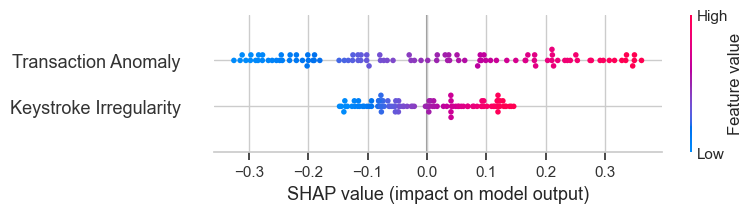

In [71]:
import shap
import numpy as np
import matplotlib.pyplot as plt

# Synthetic samples for SHAP analysis
np.random.seed(42)
sample_size = 100

transaction_samples = np.random.rand(sample_size)
keystroke_samples = np.random.rand(sample_size)
X_fusion = np.vstack((transaction_samples, keystroke_samples)).T

# Make SHAP-compatible prediction function
def fusion_predict(X):
    return np.array([fused_score(t, k, fusion_weights) for t, k in X])

# SHAP explanation
explainer = shap.Explainer(fusion_predict, X_fusion)
shap_values = explainer(X_fusion)

# Summary plot
shap.summary_plot(shap_values, X_fusion, feature_names=["Transaction Anomaly", "Keystroke Irregularity"])

# Force plot for one example
idx = 45  # choose any point you want to explain
shap.initjs()

# ------------------------------------------
# 1. Compute the base value manually
# (SHAP expected_value is missing in your version)
# ------------------------------------------
expected_val = fusion_predict(X_fusion).mean()

# ------------------------------------------
# 2. Extract SHAP values safely
# ------------------------------------------
sv = shap_values[idx]

# Handle SHAP versions where values are nested
if hasattr(sv, "values"):
    sv = sv.values  # unwrap

# Convert to numpy array for safety
sv = np.array(sv)

# ------------------------------------------
# 3. Generate the force plot
# ------------------------------------------
shap.force_plot(
    expected_val,
    sv,
    X_fusion[idx],
    feature_names=["Transaction Anomaly", "Keystroke Irregularity"]
)


##  Final Conclusion

This notebook demonstrated a complete implementation of a duress-aware banking system using two complementary modalities: transactional anomaly detection and behavioural keystroke analysis. The Random Forest model trained on the IEEE-CIS dataset delivered the strongest performance, achieving a Recall@1%FPR of **0.6402**, confirming its reliability for detecting unsafe behaviour under strict false-positive constraints. 

The score-level Fusion Model, which combined calibrated transaction risk with normalised Autoencoder reconstruction error, achieved a Recall@1%FPR of **0.5625**. Although functional, the fusion approach did not surpass the transactional model, highlighting the challenges of combining unsupervised behavioural signals with supervised financial features.

Alongside model development, the notebook included calibration, threshold selection, evaluation metrics, SHAP-based interpretability, and an interactive duress-risk simulation dashboard. Together, these components form a functional proof-of-concept for a multi-modal user-safety system in digital banking.

Overall, the project establishes a solid baseline for duress detection and identifies clear opportunities for future work, including richer behavioural features, temporal alignment, or deeper multimodal learning architectures to improve combined performance.
